## Testing Vectorizing Common Words in Unique Text Columns

Import after dimensionality reduction part of script

In [159]:
import os
os.getcwd()
#os.chdir("/Users/ellawileman/Documents/spring2025/dsci2/dsci2_final_project")

'/Users/ellawileman/Documents/spring2025/dsci2/dsci2_final_project'

In [160]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
#jobs = pd.read_csv("fake_job_postings.csv")
jobs = pd.read_csv("jobs_clean.csv")

For AI detector library:

In [161]:
!pip install transformers torch

* Need to run below cell the first time you use!! JK ended up being too computationally expensive to run the AI detector packages

In [162]:
'''
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Pre-load model and tokenizer
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased")
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Then create the pipeline manually
from transformers import TextClassificationPipeline
classifier = TextClassificationPipeline(model=model, tokenizer=tokenizer)

# Test inference
text = "This is an example of text."
output = classifier(text)
print(output)
'''


'\nfrom transformers import AutoModelForSequenceClassification, AutoTokenizer\n\n# Pre-load model and tokenizer\nmodel = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased")\ntokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")\n\n# Then create the pipeline manually\nfrom transformers import TextClassificationPipeline\nclassifier = TextClassificationPipeline(model=model, tokenizer=tokenizer)\n\n# Test inference\ntext = "This is an example of text."\noutput = classifier(text)\nprint(output)\n'

In [163]:
'''
from transformers import pipeline
# Load AI text detector pipeline
classifier = pipeline("text-classification", model="distilbert-base-uncased")
'''

'\nfrom transformers import pipeline\n# Load AI text detector pipeline\nclassifier = pipeline("text-classification", model="distilbert-base-uncased")\n'

In [164]:
jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 32 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   department                         6327 non-null   object
 1   company_profile                    14572 non-null  object
 2   description                        17878 non-null  object
 3   requirements                       15182 non-null  object
 4   benefits                           10660 non-null  object
 5   telecommuting                      17880 non-null  int64 
 6   has_company_logo                   17880 non-null  int64 
 7   has_questions                      17880 non-null  int64 
 8   employment_type                    14409 non-null  object
 9   industry                           12977 non-null  object
 10  function                           11425 non-null  object
 11  fraudulent                         17880 non-null  int64 
 12  filt

1. vectorize "description" column and get top most frequent words as attributes
2. one-hot encode all other columns
3. stack them so we can train model on vectorized description AND other columns. We can repeat this for other high cardinality string type attributes.

In [165]:
jobs.nunique()

department                             143
company_profile                       1709
description                          14665
requirements                         11898
benefits                              6079
telecommuting                            2
has_company_logo                         2
has_questions                            2
employment_type                          5
industry                                80
function                                37
fraudulent                               2
filtered_industry                       50
Salary Given                             2
Grouped_Titles                       10909
Country                                 91
Region                                 325
City                                  2218
special_characters                       2
Bachelor_degree                          2
High school or equivalent                2
Unspecified degree requirement           2
Masters_degree                           2
Associates 

Further grouping job titles: methodology is open to some review -- nothing is final

In [166]:

from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
import string
default_stopwords = set(stopwords.words('english'))
# Assuming 'Grouped_Titles' is the column of interest
grouped_titles = jobs['Grouped_Titles'].fillna('')  # Replace NaN with empty strings
one_letter_words = set(string.ascii_lowercase)  # a, b, c, ..., z

# Combine the default stopwords with one-letter and two-letter words
extended_stopwords = default_stopwords.union(one_letter_words)
extended_stopwords = list(extended_stopwords)


# Preprocess the text
grouped_titles = grouped_titles.str.replace(r'\d+', '', regex=True)  # Remove numbers
grouped_titles = grouped_titles.str.replace(r'\byear olds?\b', '', regex=True, case=False)  # Remove "year olds"
grouped_titles = grouped_titles.str.replace(r'[^a-zA-Z\s]', '', regex=True)  # Remove non-alphabetic characters

# Adjustable thresholds
BIGRAM_THRESHOLD = 200  # Increase the number of top bigrams
UNIGRAM_THRESHOLD = 200  # Increase the number of top unigrams

# Step 1: Extract Bigrams
vectorizer_bigrams = CountVectorizer(ngram_range=(2, 2), stop_words=extended_stopwords, token_pattern=r'\b[a-zA-Z]+\b')
bigrams = vectorizer_bigrams.fit_transform(grouped_titles)

# Get the top bigrams
bigram_counts = bigrams.sum(axis=0)
bigram_frequencies = [(phrase, bigram_counts[0, idx]) for phrase, idx in vectorizer_bigrams.vocabulary_.items()]
bigram_frequencies = sorted(bigram_frequencies, key=lambda x: x[1], reverse=True)
top_bigrams = [phrase for phrase, count in bigram_frequencies[:BIGRAM_THRESHOLD]]

# Step 2: Extract Unigrams
vectorizer_unigrams = CountVectorizer(ngram_range=(1, 1), stop_words=extended_stopwords, token_pattern=r'\b[a-zA-Z]+\b')
unigrams = vectorizer_unigrams.fit_transform(grouped_titles)

# Get the top unigrams
unigram_counts = unigrams.sum(axis=0)
unigram_frequencies = [(word, unigram_counts[0, idx]) for word, idx in vectorizer_unigrams.vocabulary_.items()]
unigram_frequencies = sorted(unigram_frequencies, key=lambda x: x[1], reverse=True)
top_unigrams = [word for word, count in unigram_frequencies[:UNIGRAM_THRESHOLD]]

def map_to_bigram_or_unigram(title):
    # Check for specific bigrams first
    for bigram in top_bigrams:
        if bigram in title.lower():
            return bigram
    # Fallback to generic unigrams
    for unigram in top_unigrams:
        if unigram in title.lower():
            return unigram
    return "Other"


# Step 5: Apply the Mapping
jobs['Mapped_Title'] = grouped_titles.apply(lambda title: map_to_bigram_or_unigram(title))

# Analyze the distribution of groups
group_distribution = jobs['Mapped_Title'].value_counts()
print(group_distribution)

# Display the percentage of "Other"
percent_other = (group_distribution['Other'] / len(jobs)) * 100
print(f"Percentage of 'Other': {percent_other:.2f}%")

# don't want too many titles to be placed into other (loss of detail/info)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ellawileman/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Mapped_Title
manager               761
customer service      750
english teacher       721
Other                 696
engineer              628
                     ... 
rails                   1
beauty promotional      1
experience              1
insurance               1
entry clerk             1
Name: count, Length: 323, dtype: int64
Percentage of 'Other': 3.89%


In [167]:
# now want to group very low frequency titles into "Other"
MIN_FREQUENCY = 30  # Set the minimum frequency threshold

# Get the frequency of each label
label_frequencies = jobs['Mapped_Title'].value_counts()

# Identify labels below the threshold
low_frequency_labels = label_frequencies[label_frequencies < MIN_FREQUENCY].index

# Reassign low-frequency labels to "Other"
jobs['Mapped_Title'] = jobs['Mapped_Title'].apply(lambda x: "Other" if x in low_frequency_labels else x)

# Reanalyze the distribution of groups
group_distribution = jobs['Mapped_Title'].value_counts()

# Display the updated percentage of "Other"
percent_other = (group_distribution['Other'] / len(jobs)) * 100
print(f"Updated Percentage of 'Other': {percent_other:.2f}%")

display(group_distribution)

Updated Percentage of 'Other': 16.68%


Mapped_Title
Other                     2982
manager                    761
customer service           750
english teacher            721
engineer                   628
                          ... 
recruitment consultant      30
technical                   30
junior                      30
frontend engineer           30
title closer                30
Name: count, Length: 145, dtype: int64

Replicating logic to drop high-cardinality attributes (but plus description)

In [168]:
# X = jobs["description"]

# getting description, company profile, requirements attributes to tokenize
unique_values = jobs.nunique() 
selected_columns = unique_values[(unique_values <= 145) | (unique_values == 14665) | (unique_values == 1708) | (unique_values == 1709)| (unique_values == 11898) | (unique_values == 6079)].index

# Create a new DataFrame with selected columns
new_df = jobs[selected_columns]
pre_text_mining = jobs[selected_columns]
new_df.columns

Index(['department', 'company_profile', 'description', 'requirements',
       'benefits', 'telecommuting', 'has_company_logo', 'has_questions',
       'employment_type', 'industry', 'function', 'fraudulent',
       'filtered_industry', 'Salary Given', 'Country', 'special_characters',
       'Bachelor_degree', 'High school or equivalent',
       'Unspecified degree requirement', 'Masters_degree', 'Associates degree',
       'Certification', 'Some College Coursework Completed', 'Mid-Senior',
       'Entry level', 'Associate', 'Not Application', 'Director', 'Internship',
       'Mapped_Title'],
      dtype='object')

Vectorize description column and company profile column using TfidfVectorizer (top 100 words)

In [169]:
'''
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import nltk
import string

# Replace NaN values in 'description' and 'company_profile' with empty strings
new_df['description'] = new_df['description'].fillna('')
new_df['company_profile'] = new_df['company_profile'].fillna('')
new_df['requirements'] = new_df['requirements'].fillna('')
new_df["benefits"] = new_df["benefits"].fillna('')

# Remove numbers directly from the text columns
new_df['description'] = new_df['description'].str.replace(r'\d+', '', regex=True)
new_df['company_profile'] = new_df['company_profile'].str.replace(r'\d+', '', regex=True)
new_df['requirements'] = new_df['requirements'].str.replace(r'\d+', '', regex=True)
new_df['benefits'] = new_df['benefits'].str.replace(r'\d+', '', regex=True)

# modifying stopwords list to excluse any one or two letter words
nltk.download('stopwords')
# Load default English stopwords
default_stopwords = set(stopwords.words('english'))
one_letter_words = set(string.ascii_lowercase)  # a, b, c, ..., z
two_letter_words = {a + b for a in string.ascii_lowercase for b in string.ascii_lowercase}  # aa, ab, ..., zz
# Combine default stopwords with one- and two-letter words
custom_stopwords = default_stopwords.union(one_letter_words).union(two_letter_words)
# Convert the stopwords set to a list (required by TfidfVectorizer)
custom_stopwords = list(custom_stopwords)

# Initialize TfidfVectorizer
vectorizer_description = TfidfVectorizer(ngram_range=(2, 5), max_features=100, stop_words=custom_stopwords)  # For description
vectorizer_company = TfidfVectorizer(ngram_range=(2, 5), max_features=100, stop_words=custom_stopwords)  # For company_profile
vectorizer_requirements = TfidfVectorizer(ngram_range=(2, 5), max_features=100, stop_words=custom_stopwords)  # For requirements
vectorizer_benefits = TfidfVectorizer(ngram_range=(2, 5), max_features=100, stop_words=custom_stopwords)  # For benefits

# Fit and transform the 'description' column
vectorizer_description.fit(new_df['description'])
new_df['description_vector'] = list(vectorizer_description.transform(new_df['description']).toarray())

# Fit and transform the 'company_profile' column
vectorizer_company.fit(new_df['company_profile'])
new_df['company_profile_vector'] = list(vectorizer_company.transform(new_df['company_profile']).toarray())

# Fit and transform the 'requirements' column
vectorizer_requirements.fit(new_df['requirements'])
new_df['requirements_vector'] = list(vectorizer_requirements.transform(new_df['requirements']).toarray())

# for benefits column
vectorizer_benefits.fit(new_df['benefits'])
new_df['benefits_vector'] = list(vectorizer_benefits.transform(new_df['benefits']).toarray())

# Drop the original text columns if no longer needed
new_df.drop(columns=['description', 'company_profile', 'requirements', 'benefits'], inplace=True)

# Print the selected features for both columns
print("Description Features:", vectorizer_description.get_feature_names_out())
print("Company Profile Features:", vectorizer_company.get_feature_names_out())
'''

'\nfrom sklearn.feature_extraction.text import TfidfVectorizer\nfrom nltk.corpus import stopwords\nimport nltk\nimport string\n\n# Replace NaN values in \'description\' and \'company_profile\' with empty strings\nnew_df[\'description\'] = new_df[\'description\'].fillna(\'\')\nnew_df[\'company_profile\'] = new_df[\'company_profile\'].fillna(\'\')\nnew_df[\'requirements\'] = new_df[\'requirements\'].fillna(\'\')\nnew_df["benefits"] = new_df["benefits"].fillna(\'\')\n\n# Remove numbers directly from the text columns\nnew_df[\'description\'] = new_df[\'description\'].str.replace(r\'\\d+\', \'\', regex=True)\nnew_df[\'company_profile\'] = new_df[\'company_profile\'].str.replace(r\'\\d+\', \'\', regex=True)\nnew_df[\'requirements\'] = new_df[\'requirements\'].str.replace(r\'\\d+\', \'\', regex=True)\nnew_df[\'benefits\'] = new_df[\'benefits\'].str.replace(r\'\\d+\', \'\', regex=True)\n\n# modifying stopwords list to excluse any one or two letter words\nnltk.download(\'stopwords\')\n# Load de

In [170]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import nltk
import string

# Download NLTK stopwords
nltk.download('stopwords')

# Fill NaNs
text_cols = ['description', 'company_profile', 'requirements', 'benefits']
for col in text_cols:
    new_df[col] = new_df[col].fillna('')
    new_df[col] = new_df[col].str.replace(r'\d+', '', regex=True)

# Stopwords + short words filtering
default_stopwords = set(stopwords.words('english'))
one_letter_words = set(string.ascii_lowercase)
two_letter_words = {a + b for a in string.ascii_lowercase for b in string.ascii_lowercase}
custom_stopwords = list(default_stopwords.union(one_letter_words).union(two_letter_words))

def filter_ngrams(feature_names, tfidf_matrix, min_diff=0.2):
    """
    Filters out shorter n-grams if longer versions exist and are similarly frequent.
    Keeps shorter ones only if their overall importance is significantly higher.
    """
    import numpy as np
    from collections import defaultdict

    feature_scores = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
    name_score_map = dict(zip(feature_names, feature_scores))
    to_remove = set()

    feature_set = set(feature_names)
    for short in feature_names:
        for long in feature_names:
            if short != long and short in long:
                if name_score_map[long] >= name_score_map[short] * (1 - min_diff):
                    to_remove.add(short)
    
    return [ngram for ngram in feature_names if ngram not in to_remove]
filtered_feature_map = {}

def vectorize_and_store(column, name):
    vectorizer = TfidfVectorizer(ngram_range=(2, 5), max_features=75, stop_words=custom_stopwords)
    tfidf_matrix = vectorizer.fit_transform(new_df[column])
    feature_names = vectorizer.get_feature_names_out()
    filtered_features = filter_ngrams(feature_names, tfidf_matrix)
    
    # Save the filtered features globally
    filtered_feature_map[name] = filtered_features

    # Keep only the selected columns
    selected_indices = [i for i, f in enumerate(feature_names) if f in filtered_features]
    reduced_matrix = tfidf_matrix[:, selected_indices]
    
    new_df[f'{name}_vector'] = list(reduced_matrix.toarray())
    print(f"{name.title()} Features:", filtered_features)

# Apply vectorization
vectorize_and_store('description', 'description')
vectorize_and_store('company_profile', 'company_profile')
vectorize_and_store('requirements', 'requirements')
vectorize_and_store('benefits', 'benefits')

# Drop original text columns
new_df.drop(columns=text_cols, inplace=True)


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ellawileman/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/var/folders/yz/btvl331d4g54624wdzgx_2hc0000gn/T/ipykernel_69666/3162276664.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df[col] = new_df[col].fillna('')
/var/folders/yz/btvl331d4g54624wdzgx_2hc0000gn/T/ipykernel_69666/3162276664.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df[col] = new_df[col].str.replace(r'\d+', '', regex=True)
/var/fo

Description Features: ['apply directly', 'asia usd monthly cost living', 'business development', 'cardsgabriel adkins url_edcbafbeedcdbdeccddacfdf url_dbdfcdbecfcabaeaacbfdeb', 'click apply', 'communication skills', 'customer service', 'day day', 'development team', 'fast growing', 'fast paced', 'feel free', 'front end', 'full time', 'get paid', 'high quality', 'ideal candidate', 'include limited', 'integral part', 'join team', 'kids get paid love travel', 'long term', 'new business', 'new york', 'part time', 'per week', 'play kids get paid love', 'products services', 'reimbursedexcellent student loans credit', 'responsibilities include', 'right candidate', 'sales team', 'social media', 'student loans credit cardsgabriel adkins', 'team members', 'usd monthly cost living housing', 'work closely', 'years experience']


/var/folders/yz/btvl331d4g54624wdzgx_2hc0000gn/T/ipykernel_69666/3162276664.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df[f'{name}_vector'] = list(reduced_matrix.toarray())


Company_Profile Features: ['around world', 'candidates engineering manufacturing highly technical', 'customer satisfaction', 'document communications', 'finding recruiting high quality candidates', 'full time', 'full time permanent positions many', 'get safe amp secure jobs', 'help teachers get safe amp', 'high quality', 'highly technical non technical jobs', 'increase productivity', 'interested finding recruiting high', 'large companies interested finding recruiting', 'long term', 'manufacturing highly technical non technical', 'medium large', 'medium large companies interested finding', 'new york', 'permanent positions many medium large', 'provide full time permanent', 'quality candidates engineering manufacturing', 'safe amp secure jobs abroad', 'solutions help', 'teachers get safe amp secure', 'valor services']
Requirements Features: ['ability work', 'able work', 'attention detail', 'bachelor degree', 'communication skills', 'computer science', 'customer service', 'degree required'

### Additional Text Mining: Sentiment, Subjectivity, and Readability

In [171]:
from textblob import TextBlob
import textstat
import pandas as pd

# Define text columns to analyze
text_cols = ["description", "benefits", "company_profile", "requirements"]

# Create empty DataFrame for sentiment and readability features
sentiment_df = pd.DataFrame(index=pre_text_mining.index)

# Ensure all text columns are strings and fill NaNs
for col in text_cols:
    pre_text_mining[col] = pre_text_mining[col].fillna('').astype(str)

# sentiment scoring function
def get_sentiment_scores(text):
    blob = TextBlob(text)
    return pd.Series([blob.sentiment.polarity, blob.sentiment.subjectivity])

# sentiment and readability scores
for col in text_cols:
    sentiment_scores = pre_text_mining[col].apply(get_sentiment_scores)
    sentiment_scores.columns = [f'{col}_sentiment', f'{col}_subjectivity']
    
    # Add readability scores
    readability_scores = pre_text_mining[col].apply(textstat.flesch_reading_ease)
    readability_scores.name = f'{col}_readability'
    
    # Combine into final df
    sentiment_df = pd.concat([sentiment_df, sentiment_scores, readability_scores], axis=1)

# Add word count and sentence count
def word_count(text):
    return len(text.split())

def sentence_count(text):
    return len(text.split('.'))

for col in text_cols:
    sentiment_df[f'{col}_word_count'] = pre_text_mining[col].apply(word_count)
    sentiment_df[f'{col}_sentence_count'] = pre_text_mining[col].apply(sentence_count)
# can merge with dummies df 

/var/folders/yz/btvl331d4g54624wdzgx_2hc0000gn/T/ipykernel_69666/4225945037.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pre_text_mining[col] = pre_text_mining[col].fillna('').astype(str)
/var/folders/yz/btvl331d4g54624wdzgx_2hc0000gn/T/ipykernel_69666/4225945037.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pre_text_mining[col] = pre_text_mining[col].fillna('').astype(str)
/var/folders/yz/btvl331d4g54624wdzgx_2hc0000gn/T/ipykernel_69666/4225945037.py:13: SettingWithCopyWarning: 
A value is t

In [172]:
sentiment_df.columns

Index(['description_sentiment', 'description_subjectivity',
       'description_readability', 'benefits_sentiment',
       'benefits_subjectivity', 'benefits_readability',
       'company_profile_sentiment', 'company_profile_subjectivity',
       'company_profile_readability', 'requirements_sentiment',
       'requirements_subjectivity', 'requirements_readability',
       'description_word_count', 'description_sentence_count',
       'benefits_word_count', 'benefits_sentence_count',
       'company_profile_word_count', 'company_profile_sentence_count',
       'requirements_word_count', 'requirements_sentence_count'],
      dtype='object')

/var/folders/yz/btvl331d4g54624wdzgx_2hc0000gn/T/ipykernel_69666/2548917383.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=sorted_correlation.index, x=sorted_correlation.values, palette='coolwarm')


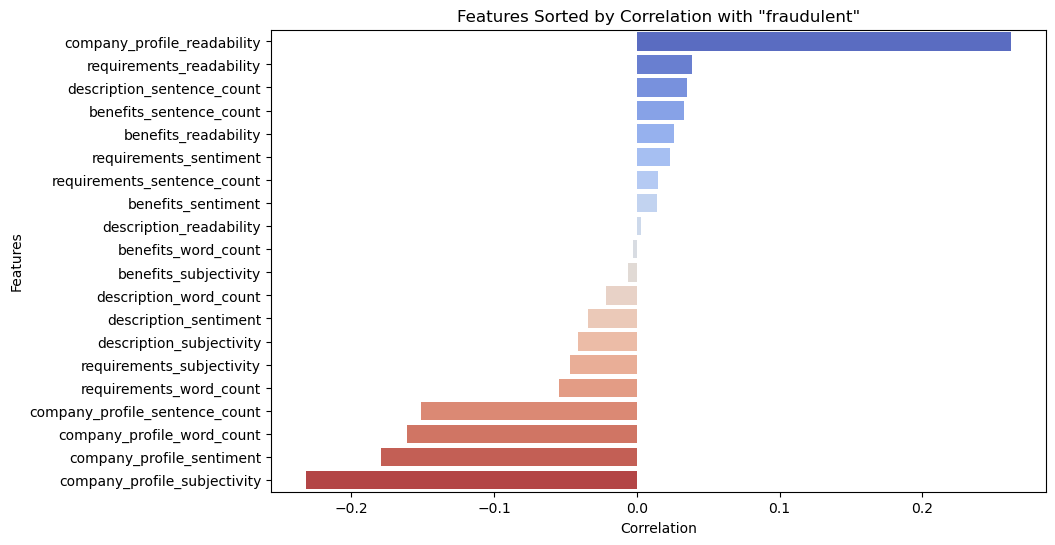

In [173]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming new_df['fraudulent'] contains the target variable
sentiment_df["fraudulent"] = new_df["fraudulent"]

# Compute the correlation matrix
correlation_matrix = sentiment_df.corr()

# Extract correlations with the class label 'fraudulent'
correlation_with_class = correlation_matrix["fraudulent"]

# Sort features by their correlation with the class label
sorted_correlation = correlation_with_class.sort_values(ascending=False)

# Drop the correlation of the target with itself (i.e., the 'fraudulent' column)
sorted_correlation = sorted_correlation.drop('fraudulent')

# Plot the sorted correlation values with swapped axes
plt.figure(figsize=(10, 6))
sns.barplot(y=sorted_correlation.index, x=sorted_correlation.values, palette='coolwarm')
plt.title(f'Features Sorted by Correlation with "fraudulent"')
plt.xlabel('Correlation')
plt.ylabel('Features')
plt.show()


In [174]:
sentiment_df = sentiment_df.drop(columns="fraudulent", axis=1)
sentiment_df.columns

Index(['description_sentiment', 'description_subjectivity',
       'description_readability', 'benefits_sentiment',
       'benefits_subjectivity', 'benefits_readability',
       'company_profile_sentiment', 'company_profile_subjectivity',
       'company_profile_readability', 'requirements_sentiment',
       'requirements_subjectivity', 'requirements_readability',
       'description_word_count', 'description_sentence_count',
       'benefits_word_count', 'benefits_sentence_count',
       'company_profile_word_count', 'company_profile_sentence_count',
       'requirements_word_count', 'requirements_sentence_count'],
      dtype='object')

In [175]:
#print("Requirements Features:", vectorizer_requirements.get_feature_names_out())

In [176]:
#print("Benefits Features:", vectorizer_benefits.get_feature_names_out())

Data preparation: storing these tokens (most frequent words) with their respective column name

In [177]:
'''
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder

# Step 1: Decompose description_vector and company_profile_vector
description_features = vectorizer_description.get_feature_names_out()
company_profile_features = vectorizer_company.get_feature_names_out()
requirements_features = vectorizer_requirements.get_feature_names_out()
benefits_features = vectorizer_benefits.get_feature_names_out()

# Add suffixes to feature names
description_feature_names = [f"description_includes_{feature}" for feature in description_features]
company_profile_feature_names = [f"companyprof_includes_{feature}" for feature in company_profile_features]
requirements_feature_names = [f"requirements_includes_{feature}" for feature in requirements_features]
benefits_feature_names = [f"benefits_includes_{feature}" for feature in benefits_features]


# Convert description_vector and company_profile_vector to DataFrames
description_df = pd.DataFrame(
    np.vstack(new_df['description_vector'].values), 
    columns=description_feature_names
)
company_profile_df = pd.DataFrame(
    np.vstack(new_df['company_profile_vector'].values), 
    columns=company_profile_feature_names
)
requirements_df = pd.DataFrame(
    np.vstack(new_df['requirements_vector'].values), 
    columns=requirements_feature_names
)
benefits_df = pd.DataFrame(
    np.vstack(new_df['benefits_vector'].values), 
    columns=benefits_feature_names
)

# Concatenate the new DataFrames with the original DataFrame
new_df = pd.concat([new_df.reset_index(drop=True), description_df, company_profile_df, requirements_df, benefits_df], axis=1)

# Drop the original vector columns if no longer needed
new_df.drop(columns=['description_vector', 'company_profile_vector', 'requirements_vector', 'benefits_vector'], inplace=True)

# Step 2: One-Hot Encode Categorical Columns
encoder = OneHotEncoder(sparse_output=False)
categorical_columns = new_df.columns.difference(['fraudulent'] + description_feature_names + company_profile_feature_names + requirements_feature_names + benefits_feature_names)
categorical_features = encoder.fit_transform(new_df[categorical_columns])

categorical_feature_names = encoder.get_feature_names_out(categorical_columns)  # Feature names for categorical features
# Combine all feature names into a single list
all_feature_names = np.concatenate([description_feature_names, company_profile_feature_names, requirements_feature_names, benefits_feature_names, categorical_feature_names])

# Combine all features into a single matrix
X = np.hstack([description_df.values, company_profile_df.values, requirements_df.values, benefits_df.values, categorical_features])
y = new_df['fraudulent'].values  # Target variable

# Check the shape of the final feature matrix
print(f"Feature matrix shape: {X.shape}")
'''

'\nimport pandas as pd\nimport numpy as np\nfrom sklearn.feature_extraction.text import TfidfVectorizer\nfrom sklearn.preprocessing import OneHotEncoder\n\n# Step 1: Decompose description_vector and company_profile_vector\ndescription_features = vectorizer_description.get_feature_names_out()\ncompany_profile_features = vectorizer_company.get_feature_names_out()\nrequirements_features = vectorizer_requirements.get_feature_names_out()\nbenefits_features = vectorizer_benefits.get_feature_names_out()\n\n# Add suffixes to feature names\ndescription_feature_names = [f"description_includes_{feature}" for feature in description_features]\ncompany_profile_feature_names = [f"companyprof_includes_{feature}" for feature in company_profile_features]\nrequirements_feature_names = [f"requirements_includes_{feature}" for feature in requirements_features]\nbenefits_feature_names = [f"benefits_includes_{feature}" for feature in benefits_features]\n\n\n# Convert description_vector and company_profile_vec

In [178]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder

# Function to convert vectors to DataFrames with prefixed column names
def decompose_vector_column(df, column, prefix, feature_names):
    return pd.DataFrame(
        np.vstack(df[column].values),
        columns=[f"{prefix}_includes_{f}" for f in feature_names]
    )

# Decompose all vector columns using the stored filtered feature names
description_features = filtered_feature_map['description']
company_profile_features = filtered_feature_map['company_profile']
requirements_features = filtered_feature_map['requirements']
benefits_features = filtered_feature_map['benefits']

# Create feature DataFrames with prefixed names
description_df = decompose_vector_column(new_df, 'description_vector', 'description', description_features)
company_profile_df = decompose_vector_column(new_df, 'company_profile_vector', 'companyprof', company_profile_features)
requirements_df = decompose_vector_column(new_df, 'requirements_vector', 'requirements', requirements_features)
benefits_df = decompose_vector_column(new_df, 'benefits_vector', 'benefits', benefits_features)

# Concatenate the new feature columns with new_df
new_df = pd.concat(
    [new_df.reset_index(drop=True), description_df, company_profile_df, requirements_df, benefits_df], 
    axis=1
)

# Drop the original vector columns
new_df.drop(columns=['description_vector', 'company_profile_vector', 'requirements_vector', 'benefits_vector'], inplace=True)

# --- One-Hot Encoding for Remaining Categorical Columns ---
# Determine feature name lists
description_feature_names = description_df.columns.tolist()
company_profile_feature_names = company_profile_df.columns.tolist()
requirements_feature_names = requirements_df.columns.tolist()
benefits_feature_names = benefits_df.columns.tolist()

# Exclude known columns to isolate categorical columns
known_columns = ['fraudulent'] + description_feature_names + company_profile_feature_names + requirements_feature_names + benefits_feature_names
categorical_columns = new_df.columns.difference(known_columns)

# One-hot encode categorical columns
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
categorical_features = encoder.fit_transform(new_df[categorical_columns])
categorical_feature_names = encoder.get_feature_names_out(categorical_columns)

# Combine all features
all_feature_names = description_feature_names + company_profile_feature_names + requirements_feature_names + benefits_feature_names + categorical_feature_names.tolist()
X = np.hstack([
    description_df.values,
    company_profile_df.values,
    requirements_df.values,
    benefits_df.values,
    categorical_features
])
y = new_df['fraudulent'].values

print(f"Feature matrix shape: {X.shape}")


Feature matrix shape: (17880, 772)


In [179]:
len(categorical_features)

17880

In [180]:
new_df.columns

Index(['department', 'telecommuting', 'has_company_logo', 'has_questions',
       'employment_type', 'industry', 'function', 'fraudulent',
       'filtered_industry', 'Salary Given',
       ...
       'benefits_includes_short term', 'benefits_includes_sick leave',
       'benefits_includes_stock options', 'benefits_includes_term disability',
       'benefits_includes_vacation hours',
       'benefits_includes_vision insurance',
       'benefits_includes_without regard race',
       'benefits_includes_work environment', 'benefits_includes_work life',
       'benefits_includes_working environment'],
      dtype='object', length=207)

Extract description_vector as Numpy array, 
one-hot-encode categorical columns
combine encoded features with description_vector
train classifier on this

In [181]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder


One hot encode all other categorical columns:

In [182]:
'''
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Separate the target column
jobs = new_df
y = jobs['fraudulent'].values
# Select all columns except 'description_vector' and 'fraudulent'
# Step 2: One-Hot Encode Categorical Columns
encoder = OneHotEncoder(sparse_output=False)
categorical_columns = new_df.columns.difference(['fraudulent'] + description_feature_names + company_profile_feature_names)
categorical_features = encoder.fit_transform(new_df[categorical_columns])

# Step 3: Combine All Features
X = np.hstack([new_df[description_feature_names + company_profile_feature_names].values, categorical_features])

# Check the shape of the final feature matrix
print(X.shape)
'''

"\nfrom sklearn.preprocessing import OneHotEncoder\nimport numpy as np\n\n# Separate the target column\njobs = new_df\ny = jobs['fraudulent'].values\n# Select all columns except 'description_vector' and 'fraudulent'\n# Step 2: One-Hot Encode Categorical Columns\nencoder = OneHotEncoder(sparse_output=False)\ncategorical_columns = new_df.columns.difference(['fraudulent'] + description_feature_names + company_profile_feature_names)\ncategorical_features = encoder.fit_transform(new_df[categorical_columns])\n\n# Step 3: Combine All Features\nX = np.hstack([new_df[description_feature_names + company_profile_feature_names].values, categorical_features])\n\n# Check the shape of the final feature matrix\nprint(X.shape)\n"

In [183]:
'''
# One-hot encode the categorical columns
categorical_features = encoder.fit_transform(jobs[categorical_columns])

# Convert description_vector to a 2D NumPy array
description_vectors = np.vstack(jobs['description_vector'].values)
company_profile_vectors = np.vstack(jobs['company_profile_vector'].values)
X = np.hstack([description_vectors, company_profile_vectors, categorical_features])

print(X.shape)  # Check the shape of the combined feature matrix
X
'''

"\n# One-hot encode the categorical columns\ncategorical_features = encoder.fit_transform(jobs[categorical_columns])\n\n# Convert description_vector to a 2D NumPy array\ndescription_vectors = np.vstack(jobs['description_vector'].values)\ncompany_profile_vectors = np.vstack(jobs['company_profile_vector'].values)\nX = np.hstack([description_vectors, company_profile_vectors, categorical_features])\n\nprint(X.shape)  # Check the shape of the combined feature matrix\nX\n"

In [184]:
# After one-hot encoding:
len(X[0])
# there are 595 attributes!
# 395 attributes from one-hot encoding categorical predictors, and 100 from each of the text features

772

Random forest classifier

In [185]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
feature_importances = model.feature_importances_

# Make predictions and evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

# Sort features by importance
sorted_indices = np.argsort(feature_importances)[::-1]  # Indices of features sorted by importance (descending)
sorted_features = [(all_feature_names[i], feature_importances[i]) for i in sorted_indices]

# Print the top 10 most important features
print("Top 10 Most Important Features:")
for feature, importance in sorted_features[:10]:
    print(f"{feature}: {importance:.4f}")

# feature importances sum up to 1

Accuracy: 0.9818
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3395
           1       0.97      0.66      0.79       181

    accuracy                           0.98      3576
   macro avg       0.98      0.83      0.89      3576
weighted avg       0.98      0.98      0.98      3576

Top 10 Most Important Features:
has_company_logo_1: 0.0340
Mapped_Title_data entry: 0.0326
has_company_logo_0: 0.0289
industry_Oil & Energy: 0.0200
function_Administrative: 0.0162
filtered_industry_Oil & Energy: 0.0152
description_includes_per week: 0.0140
description_includes_part time: 0.0127
benefits_includes_work life: 0.0123
description_includes_get paid: 0.0111


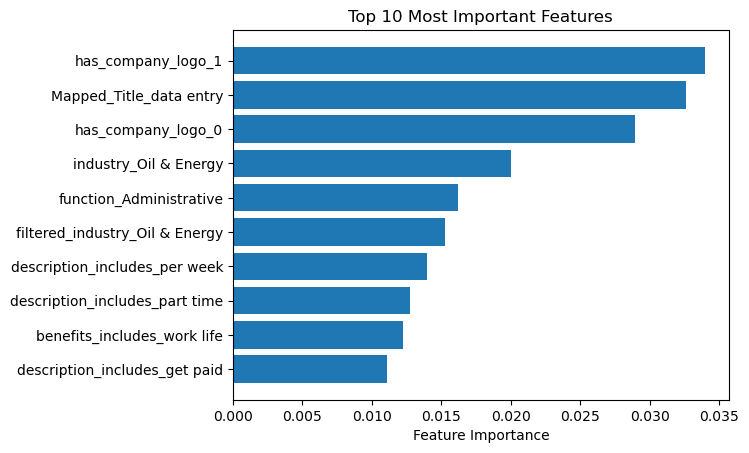

In [186]:
import matplotlib.pyplot as plt

# Plot feature importances
sorted_indices = np.argsort(feature_importances)[::-1]
top_features = sorted_indices[:10]  # Top 10 features
plt.barh(range(10), feature_importances[top_features])
plt.yticks(range(10), [all_feature_names[i] for i in top_features])
plt.xlabel("Feature Importance")
plt.title("Top 10 Most Important Features")
plt.gca().invert_yaxis()
plt.show()

# we expect that feature importance will be low! 

In [187]:
# Smote LR Model
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
smote = SMOTE(sampling_strategy='auto', random_state=42)  # auto balances the classes
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
model_smote = LogisticRegression(max_iter=1000, class_weight='balanced')
model_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = model_smote.predict(X_test)
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.99      0.94      0.97      3395
           1       0.45      0.85      0.59       181

    accuracy                           0.94      3576
   macro avg       0.72      0.89      0.78      3576
weighted avg       0.96      0.94      0.95      3576



Small improvement in metrics from version where all these variables are dropped. May see even better model performance with other variable-length string attributes.

We can repeat this methodology with other unique text columns like company description, requirements, benefits. Can also use digram, bigrams, etc. to get most common phrases

Maybe we can continue to group titles more by establishing some hierarchy, same with locations/region

Can we group these vectorized words at all? Try a different type of vectorizer that puts nearby words next to each other numerically (maybe an "includes" function would also be good for groupings rather than having to do all manual mappings)

### Start applying dimensionality reduction techniques

In [188]:
print(f"Currently there are {X_train_smote.shape[1]} columns")

Currently there are 772 columns


In [189]:
# from sklearn.feature_selection import RFECV

# selector = RFECV(estimator=model, step=1, cv=5, scoring='r2')
# selector.fit(X_train, y_train)

# print("Optimal number of features:", selector.n_features_)
# print("Selected features (boolean mask):", selector.support_)
# print("Feature ranking:", selector.ranking_)

### LDA

Projects the data onto a lower dimension space while preserving as much separation as possible. 

Starting with LDA because it is supervised while PCA is suited for unsupervised learning

In [190]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis()
# transform with lda 
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

# now Random Forest Classificiation
classifier = RandomForestClassifier(max_depth=2, random_state=0)
classifier.fit(X_train_lda, y_train)
y_pred_lda = classifier.predict(X_test_lda)

#confusion matrix 
print(classification_report(y_test, y_pred_lda))

print(X_train_lda.shape)
print(X_test.shape)


              precision    recall  f1-score   support

           0       0.98      0.99      0.98      3395
           1       0.72      0.60      0.65       181

    accuracy                           0.97      3576
   macro avg       0.85      0.79      0.82      3576
weighted avg       0.97      0.97      0.97      3576

(14304, 1)
(3576, 772)


Maybe a slight improvement because we have struck a pretty good balance between recall and precision for target = 1, but we have achieved higher results for other Random Forest models (precision was 98 and recall 64). 

#  Applying K Best for Dimensionality Reduction on the Vectorized Columns

### The columns that we are applying the transformation to: 

- Description
- Company profile
- Requirements
- Benefits

#### Kbest on non-vectorized columns

In [191]:
dropped_cols = ['description', 'benefits', 'requirements', 'company_profile']
dat = pre_text_mining.drop(columns=dropped_cols)
dat.drop(columns="industry", inplace=True) # because already have filtered industry
dat.columns

Index(['department', 'telecommuting', 'has_company_logo', 'has_questions',
       'employment_type', 'function', 'fraudulent', 'filtered_industry',
       'Salary Given', 'Country', 'special_characters', 'Bachelor_degree',
       'High school or equivalent', 'Unspecified degree requirement',
       'Masters_degree', 'Associates degree', 'Certification',
       'Some College Coursework Completed', 'Mid-Senior', 'Entry level',
       'Associate', 'Not Application', 'Director', 'Internship',
       'Mapped_Title'],
      dtype='object')

In [192]:
len(dat.columns)

25

In [193]:
X = dat.drop(columns="fraudulent")
#X = X.drop(columns = dropped_cols)
X = pd.get_dummies(X, drop_first=True)
y = dat["fraudulent"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [194]:
X.shape

(17880, 483)

In [195]:
# K - best selection
'''
results = []

print(X.shape)
print(y.shape)

categ_feature_names = X_train.columns

max_k = min(200, len(categ_feature_names))

for k in range(3, max_k + 1):
    selector = SelectKBest(f_classif, k=k)
    selector.fit(X_train, y_train)
    selected_cols = description_feature_names[selector.get_support()]

    X_train_desc_k = X_train[selected_cols]
    X_test_desc_k = X_test[selected_cols]

    # fitting random forest model for assessment 

    # these models are just the subset of data so might not be great at generalizing to the rest of the data
    # hopefully since RF is a simple model it will still give a good indication of the important variables 
    
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_desc_k, y_train)

    y_pred = model.predict(X_test_desc_k)
    acc = accuracy_score(y_test, y_pred)
    
    results.append((k, acc))



# Plot accuracy vs. k
results_df = pd.DataFrame(results, columns=["k", "Validation Accuracy"])
plt.figure(figsize=(10,6))
sns.lineplot(x="k", y="Validation Accuracy", data=results_df, marker="o")
plt.title("SelectKBest - Accuracy vs Number of Features (k)")
plt.xlabel("Number of Features (k)")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()

'''

'\nresults = []\n\nprint(X.shape)\nprint(y.shape)\n\ncateg_feature_names = X_train.columns\n\nmax_k = min(200, len(categ_feature_names))\n\nfor k in range(3, max_k + 1):\n    selector = SelectKBest(f_classif, k=k)\n    selector.fit(X_train, y_train)\n    selected_cols = description_feature_names[selector.get_support()]\n\n    X_train_desc_k = X_train[selected_cols]\n    X_test_desc_k = X_test[selected_cols]\n\n    # fitting random forest model for assessment \n\n    # these models are just the subset of data so might not be great at generalizing to the rest of the data\n    # hopefully since RF is a simple model it will still give a good indication of the important variables \n    \n    model = RandomForestClassifier(n_estimators=100, random_state=42)\n    model.fit(X_train_desc_k, y_train)\n\n    y_pred = model.predict(X_test_desc_k)\n    acc = accuracy_score(y_test, y_pred)\n    \n    results.append((k, acc))\n\n\n\n# Plot accuracy vs. k\nresults_df = pd.DataFrame(results, columns=["

In [196]:
'''
best_k_index = results_df["Validation Accuracy"].idxmax()
best_k = results_df.loc[best_k_index, "k"]
best_k
'''

'\nbest_k_index = results_df["Validation Accuracy"].idxmax()\nbest_k = results_df.loc[best_k_index, "k"]\nbest_k\n'

Best k = 111 dummies 

In [197]:
# Selecting the best Features 
from sklearn.feature_selection import SelectKBest, f_classif 
k = 111
selector = SelectKBest(f_classif, k=k)
selector.fit(X_train, y_train)

selected_mask = selector.get_support()
selected_cols = X.columns[selector.get_support()]

print(len(selected_cols))
X_train_k = X_train[selected_cols]
X_test_k = X_test[selected_cols]

#X_train_k.columns

best_cat_dummies = selected_cols
print(best_cat_dummies)
best_categ_df = X[selected_cols]
best_categ_df.shape

111
Index(['telecommuting', 'has_company_logo', 'has_questions', 'Salary Given',
       'special_characters', 'Bachelor_degree', 'High school or equivalent',
       'Masters_degree', 'Certification', 'Mid-Senior',
       ...
       'Mapped_Title_part time', 'Mapped_Title_project',
       'Mapped_Title_representative', 'Mapped_Title_sales manager',
       'Mapped_Title_sales professional', 'Mapped_Title_sales representative',
       'Mapped_Title_software engineer', 'Mapped_Title_technician',
       'Mapped_Title_ux designer', 'Mapped_Title_web developer'],
      dtype='object', length=111)


/Users/ellawileman/anaconda3/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [ 15 266 277 289 296 326] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/ellawileman/anaconda3/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


(17880, 111)

In [198]:
# getting their ranking by scores
all_scores = selector.scores_

selected_scores = all_scores[selected_mask]

# X_train_k.columns

# creating a dataframe with the top selected columns and their scores 

sorted_Scores = pd.DataFrame({
    'Feature': selected_cols,
    'Score': selected_scores
}).sort_values(by = "Score", ascending=False)

print(sorted_Scores)


                            Feature        Score
88          Mapped_Title_data entry  1219.260860
1                  has_company_logo  1048.976664
60   filtered_industry_Oil & Energy   600.733253
23          department_Oil & Energy   430.661162
15              department_Clerical   367.477847
..                              ...          ...
29                 department_other     3.912275
51     filtered_industry_E-Learning     3.807655
96       Mapped_Title_ios developer     3.741817
109        Mapped_Title_ux designer     3.741817
42              function_Management     3.695118

[111 rows x 2 columns]


/var/folders/yz/btvl331d4g54624wdzgx_2hc0000gn/T/ipykernel_69666/2914902645.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_15['Normalized_Scores'] = scaler.fit_transform(top_15[['Score']])
/var/folders/yz/btvl331d4g54624wdzgx_2hc0000gn/T/ipykernel_69666/2914902645.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Score', y='Feature', data=top_15, palette='mako')


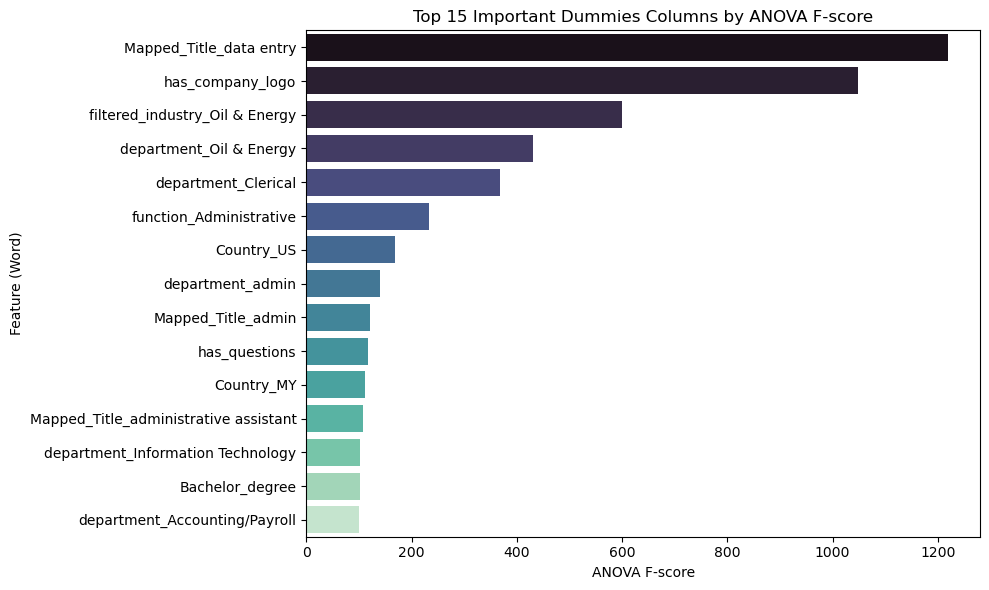

In [199]:
import seaborn as sns 
from sklearn.preprocessing import MinMaxScaler
sorted_Scores = sorted_Scores.sort_values(by = 'Score', ascending=False)
top_15 = sorted_Scores.head(15)
# Normalizing the anova score for better comparison 

scaler = MinMaxScaler()
top_15['Normalized_Scores'] = scaler.fit_transform(top_15[['Score']])


# barplot of the most important features 
plt.figure(figsize=(10,6))
sns.barplot(x='Score', y='Feature', data=top_15, palette='mako')
plt.title(f'Top 15 Important Dummies Columns by ANOVA F-score')
plt.xlabel('ANOVA F-score')
plt.ylabel('Feature (Word)')
plt.tight_layout()
plt.show()

#### Description - with 38 columns 

In [200]:
description_df.shape

(17880, 38)

In [201]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.metrics import roc_auc_score

#### Creating a dataframe with just the exploded Description Column 

In [202]:
print(new_df.shape)

description_df['fraudulent'] = new_df['fraudulent']

X = description_df.drop(columns="fraudulent")
y = description_df["fraudulent"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


(17880, 207)


(17880, 38)
(17880,)


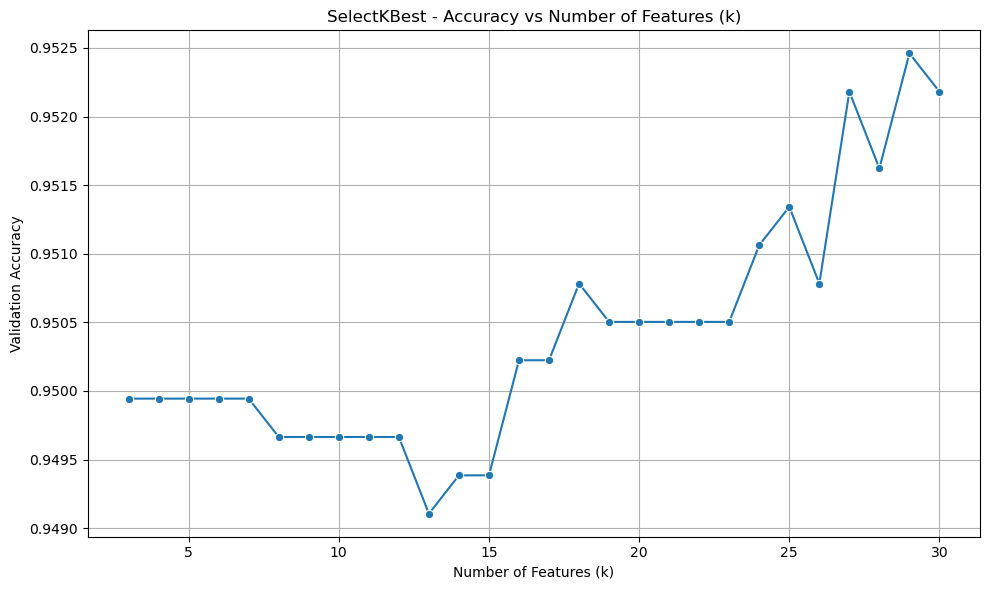

In [203]:
# K - best selection

results = []

print(X.shape)
print(y.shape)

description_feature_names = X_train.columns

max_k = min(30, len(description_feature_names))

for k in range(3, max_k + 1):
    selector = SelectKBest(f_classif, k=k)
    selector.fit(X_train, y_train)
    selected_cols = description_feature_names[selector.get_support()]

    X_train_desc_k = X_train[selected_cols]
    X_test_desc_k = X_test[selected_cols]

    # fitting random forest model for assessment 

    # these models are just the subset of data so might not be great at generalizing to the rest of the data
    # hopefully since RF is a simple model it will still give a good indication of the important variables 
    
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_desc_k, y_train)

    y_pred = model.predict(X_test_desc_k)
    acc = accuracy_score(y_test, y_pred)
    
    results.append((k, acc))



# Plot accuracy vs. k
results_df = pd.DataFrame(results, columns=["k", "Validation Accuracy"])
plt.figure(figsize=(10,6))
sns.lineplot(x="k", y="Validation Accuracy", data=results_df, marker="o")
plt.title("SelectKBest - Accuracy vs Number of Features (k)")
plt.xlabel("Number of Features (k)")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()



Skipping step one of removing highly correlated variables - can do that just not sure if we need?

##### Selecting K Best for description 

(17880, 38)
(17880,)


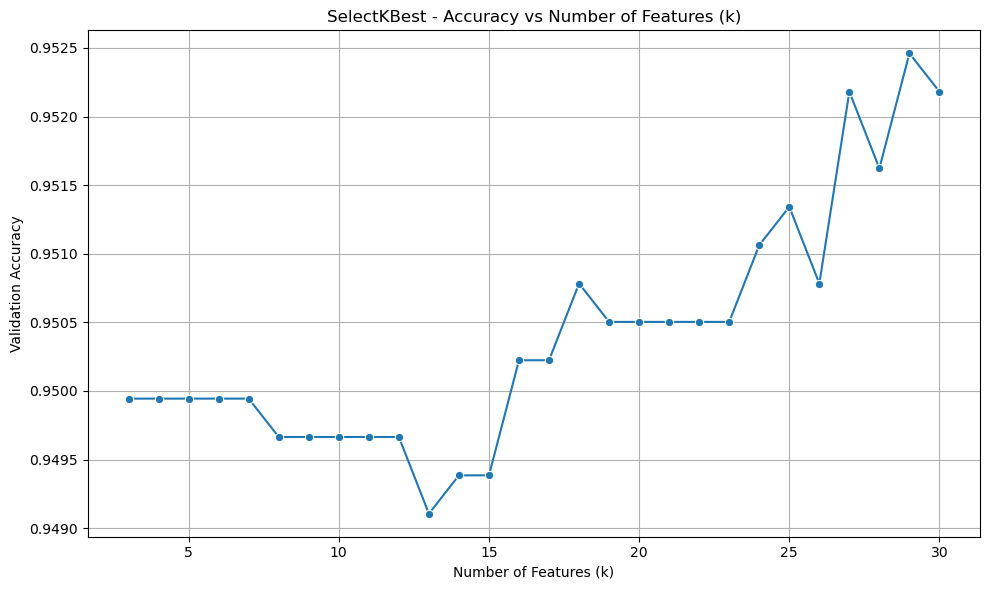

In [204]:
# K - best selection

results = []

print(X.shape)
print(y.shape)

description_feature_names = X_train.columns

max_k = min(30, len(description_feature_names))

for k in range(3, max_k + 1):
    selector = SelectKBest(f_classif, k=k)
    selector.fit(X_train, y_train)
    selected_cols = description_feature_names[selector.get_support()]

    X_train_desc_k = X_train[selected_cols]
    X_test_desc_k = X_test[selected_cols]

    # fitting random forest model for assessment 

    # these models are just the subset of data so might not be great at generalizing to the rest of the data
    # hopefully since RF is a simple model it will still give a good indication of the important variables 
    
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_desc_k, y_train)

    y_pred = model.predict(X_test_desc_k)
    acc = accuracy_score(y_test, y_pred)
    
    results.append((k, acc))



# Plot accuracy vs. k
results_df = pd.DataFrame(results, columns=["k", "Validation Accuracy"])
plt.figure(figsize=(10,6))
sns.lineplot(x="k", y="Validation Accuracy", data=results_df, marker="o")
plt.title("SelectKBest - Accuracy vs Number of Features (k)")
plt.xlabel("Number of Features (k)")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()



#### Extracting the most important features from Description

In [205]:
# Selecting the best Features 
k = 18
selector = SelectKBest(f_classif, k=k)
selector.fit(X_train, y_train)

selected_mask = selector.get_support()
selected_cols = description_feature_names[selected_mask]

# top features extracted 
X_train_k = X_train[selected_cols]
X_test_k = X_test[selected_cols]

X_train_k.columns

description_selected_cols = selected_cols

#### Creating a dataframe with K best columns

In [206]:
# getting their ranking by scores
all_scores = selector.scores_

selected_scores = all_scores[selected_mask]

# X_train_k.columns

# creating a dataframe with the top selected columns and their scores 

sorted_Scores = pd.DataFrame({
    'Feature': selected_cols,
    'Score': selected_scores
}).sort_values(by = "Score", ascending=False)

print(sorted_Scores)

                                              Feature       Score
11                     description_includes_part time  122.049585
7                       description_includes_get paid   89.685768
12                      description_includes_per week   71.354220
15                  description_includes_social media   29.483447
0   description_includes_asia usd monthly cost living   26.102548
17  description_includes_usd monthly cost living h...   25.322310
14  description_includes_reimbursedexcellent stude...   25.035140
8                  description_includes_integral part   24.931032
13       description_includes_play kids get paid love   24.761853
9      description_includes_kids get paid love travel   24.761853
1   description_includes_cardsgabriel adkins url_e...   24.347315
16  description_includes_student loans credit card...   24.347315
4                   description_includes_fast growing   24.058200
10                     description_includes_long term   23.177946
5         

/var/folders/yz/btvl331d4g54624wdzgx_2hc0000gn/T/ipykernel_69666/2678107507.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Normalized_Scores', y='shorter_names', data=sorted_Scores, palette='mako')


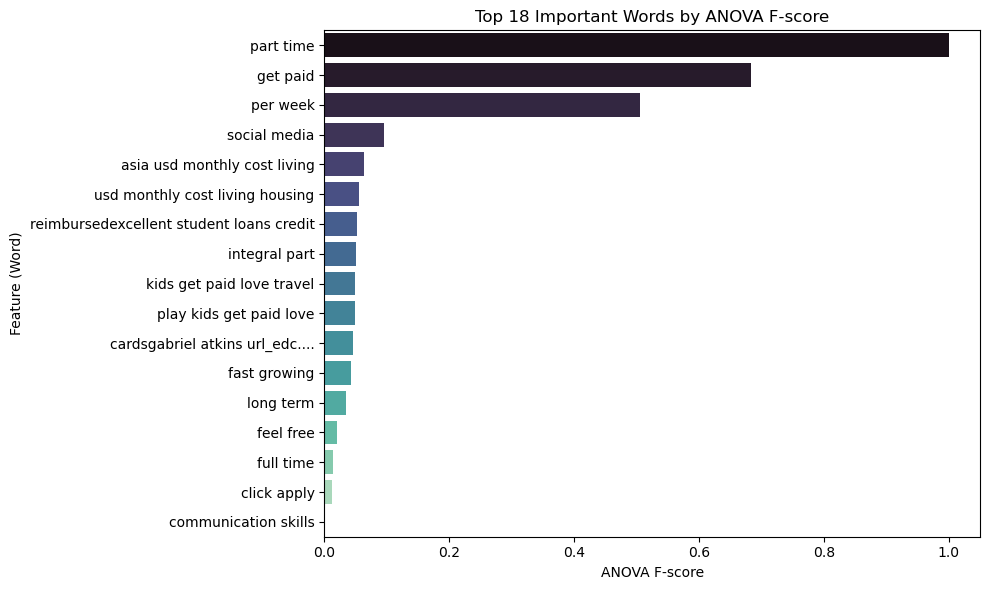

In [207]:
# trimming the feature name for clean visualization


sorted_Scores['shorter_names'] = sorted_Scores['Feature'].str.replace("description_includes_", "", regex= False)

# trimming the long url 

if sorted_Scores['shorter_names'].str.contains("cardsgabriel").any():
    sorted_Scores['shorter_names'] = sorted_Scores['shorter_names'].apply(
        lambda x: 'cardsgabriel atkins url_edc....' if 'cardsgabriel' in x else x
    )

sorted_Scores = sorted_Scores.sort_values(by = 'Score', ascending=False)

# Normalizing the anova score for better comparison 

scaler = MinMaxScaler()
sorted_Scores['Normalized_Scores'] = scaler.fit_transform(sorted_Scores[['Score']])


# barplot of the most important features 
plt.figure(figsize=(10,6))
sns.barplot(x='Normalized_Scores', y='shorter_names', data=sorted_Scores, palette='mako')
plt.title(f'Top {k} Important Words by ANOVA F-score')
plt.xlabel('ANOVA F-score')
plt.ylabel('Feature (Word)')
plt.tight_layout()
plt.show()

In [208]:
X_train_description = X_train_k 
print(X_train_description.shape)

(14304, 18)


#### Company Profile - with 26

In [209]:
print(company_profile_df.shape)


(17880, 26)


In [210]:
# subset data frame with company profile columns 

company_profile_df['fraudulent'] = new_df['fraudulent']

X = company_profile_df.drop(columns="fraudulent")
y = company_profile_df["fraudulent"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




(17880, 26)
(17880,)


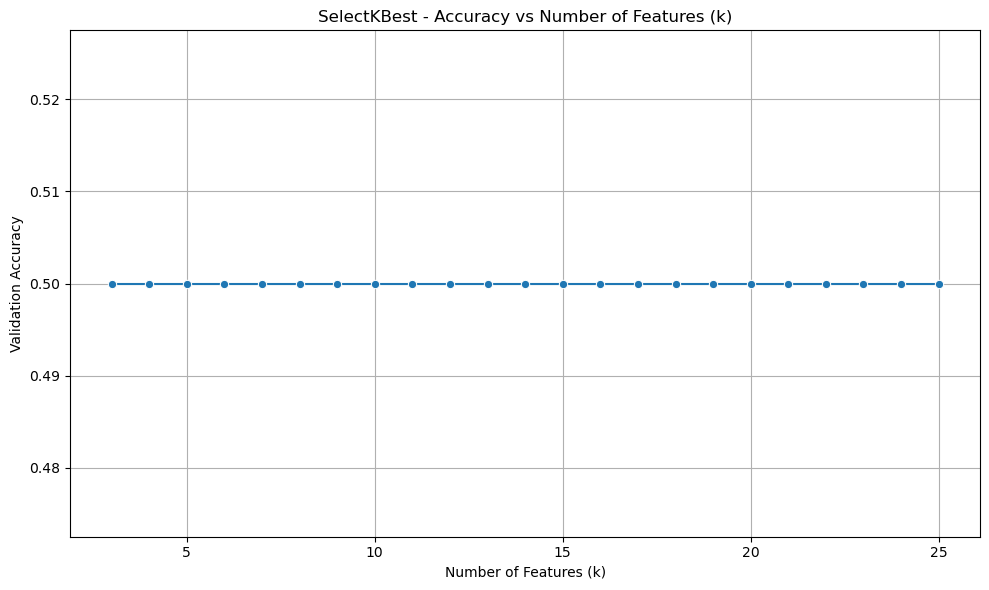

In [211]:
results = []

print(X.shape)
print(y.shape)

description_feature_names = X_train.columns

max_k = min(25, len(description_feature_names))

for k in range(3, max_k + 1):
    selector = SelectKBest(f_classif, k=k)
    selector.fit(X_train, y_train)
    selected_cols = description_feature_names[selector.get_support()]

    X_train_desc_k = X_train[selected_cols]
    X_test_desc_k = X_test[selected_cols]

    # fitting random forest model for assessment 

    model = LogisticRegression(max_iter=100)
    model.fit(X_train_desc_k, y_train)

    y_pred = model.predict(X_test_desc_k)
    auc = roc_auc_score(y_test, y_pred)
    
    results.append((k, auc))

# Plot accuracy vs. k
results_df = pd.DataFrame(results, columns=["k", "Validation Accuracy"])
plt.figure(figsize=(10,6))
sns.lineplot(x="k", y="Validation Accuracy", data=results_df, marker="o")
plt.title("SelectKBest - Accuracy vs Number of Features (k)")
plt.xlabel("Number of Features (k)")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()

Not so sure what is going on there! Will look into more 

##### Lasso to try to reduce dimensionality 

In [212]:

logreg = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)

logreg.fit(X_train, y_train)

coef = logreg.coef_[0]
features_names = X_train.columns

selected_mask = coef != 0
profile_selected_features = features_names[selected_mask]

profile_selected_features.shape

(14,)

In [213]:
selected_features_with_weights = list(zip(features_names[selected_mask], coef[selected_mask]))

# sorted by absolute value of the weight, descending (same effect as selector's feature importance above)
sorted_features = sorted(selected_features_with_weights, key=lambda x: abs(x[1]), reverse=True)

# Print them
for feature, weight in sorted_features:
    print(f"{feature}: {weight:.4f}")

companyprof_includes_teachers get safe amp secure: -5.4363
companyprof_includes_high quality: -5.1734
companyprof_includes_full time: -4.8340
companyprof_includes_get safe amp secure jobs: -4.3951
companyprof_includes_around world: -3.7621
companyprof_includes_long term: -2.9131
companyprof_includes_new york: -2.8799
companyprof_includes_customer satisfaction: -2.8597
companyprof_includes_medium large: -2.8177
companyprof_includes_solutions help: -2.4648
companyprof_includes_valor services: -2.2519
companyprof_includes_increase productivity: -1.1165
companyprof_includes_safe amp secure jobs abroad: -0.0469
companyprof_includes_help teachers get safe amp: -0.0063


/var/folders/yz/btvl331d4g54624wdzgx_2hc0000gn/T/ipykernel_69666/3636452645.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Normalized_Scores', y='Feature', data=sorted_Scores, palette='mako')


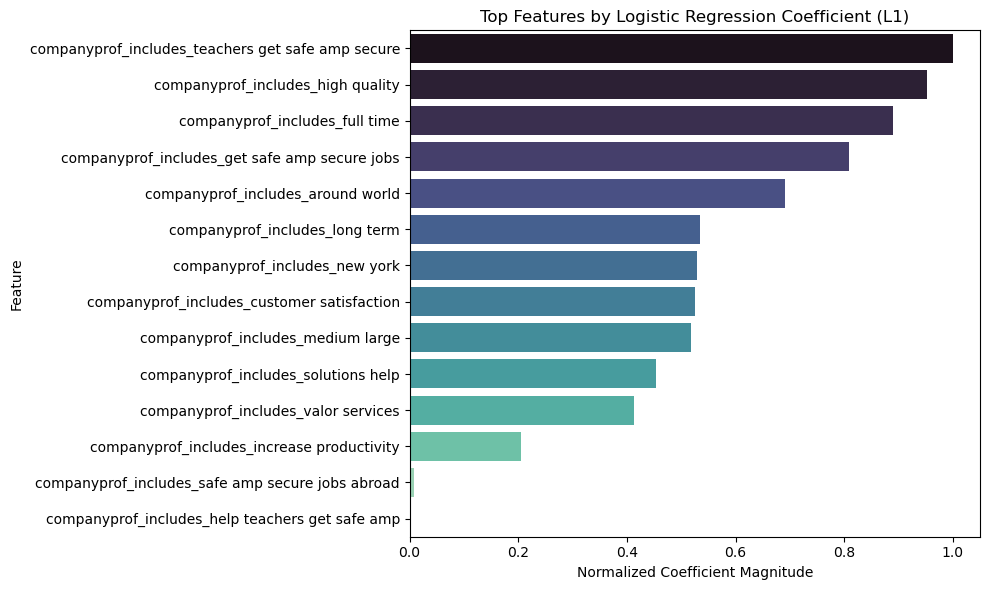

In [214]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
sorted_Scores = pd.DataFrame(sorted_features, columns=['Feature', 'Score'])

# Normalize absolute coefficient scores
scaler = MinMaxScaler()
sorted_Scores['Normalized_Scores'] = scaler.fit_transform(sorted_Scores[['Score']].abs())

# Sort for plotting
sorted_Scores = sorted_Scores.sort_values(by='Normalized_Scores', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Normalized_Scores', y='Feature', data=sorted_Scores, palette='mako')

plt.title('Top Features by Logistic Regression Coefficient (L1)')
plt.xlabel('Normalized Coefficient Magnitude')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()



### Requirements - with 55 columns 

In [215]:
requirements_df.shape

(17880, 55)

In [216]:
requirements_df['fraudulent'] = new_df['fraudulent']

X = requirements_df.drop(columns="fraudulent")
y = requirements_df["fraudulent"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

(17880, 55)
(17880,)


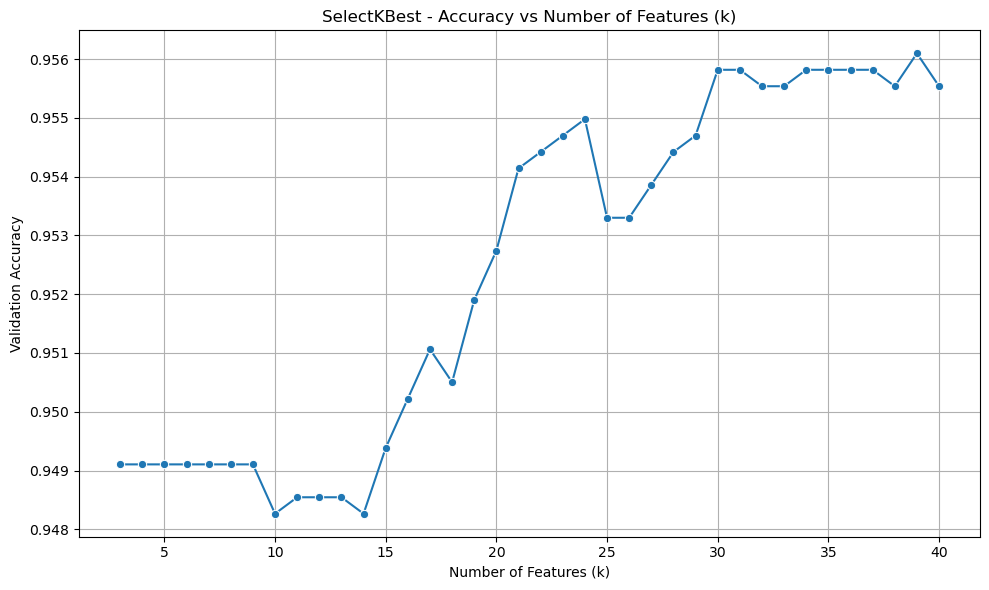

In [217]:
results = []

print(X.shape)
print(y.shape)

description_feature_names = X_train.columns

max_k = min(40, len(description_feature_names))

for k in range(3, max_k + 1):
    selector = SelectKBest(f_classif, k=k)
    selector.fit(X_train, y_train)
    selected_cols = description_feature_names[selector.get_support()]

    X_train_desc_k = X_train[selected_cols]
    X_test_desc_k = X_test[selected_cols]

    # fitting random forest model for assessment 

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_desc_k, y_train)

    y_pred = model.predict(X_test_desc_k)
    acc = accuracy_score(y_test, y_pred)
    
    results.append((k, acc))

# Plot accuracy vs. k
results_df = pd.DataFrame(results, columns=["k", "Validation Accuracy"])
plt.figure(figsize=(10,6))
sns.lineplot(x="k", y="Validation Accuracy", data=results_df, marker="o")
plt.title("SelectKBest - Accuracy vs Number of Features (k)")
plt.xlabel("Number of Features (k)")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()

In [218]:
# Selecting 17 features
# 
# OR HONESLTY WE CAN EVEN DO LIKE 3 FEATURES SINCE ADDING 10+ FEATURES ONLY CHNAGES ACCURACY BY 10THS - lets discuss this!  
k = 17
selector = SelectKBest(f_classif, k=k)
selector.fit(X_train, y_train)

selected_mask = selector.get_support()
selected_cols = description_feature_names[selected_mask]

# top features extracted 
X_train_k = X_train[selected_cols]
X_test_k = X_test[selected_cols]

# getting their ranking by scores
all_scores = selector.scores_

selected_scores = all_scores[selected_mask]

# X_train_k.columns

# creating a dataframe with the top selected columns and their scores 

sorted_Scores = pd.DataFrame({
    'Feature': selected_cols,
    'Score': selected_scores
}).sort_values(by = "Score", ascending=False)

print(sorted_Scores)
print(sorted_Scores.shape)

req_selected_cols = selected_cols
# print(req_selected_cols)


                                              Feature       Score
3                   requirements_includes_high school  100.051452
4           requirements_includes_high school diploma   70.400965
11  requirements_includes_tefl tesol celta teachin...   29.345199
2   requirements_includes_degree required tefl tes...   28.758327
15  requirements_includes_university degree requir...   28.758327
7   requirements_includes_required tefl tesol celt...   28.758327
12  requirements_includes_tesol celta teaching exp...   27.626968
6              requirements_includes_passport holders   26.533393
14            requirements_includes_university degree   25.987119
16                   requirements_includes_word excel   25.566997
8                requirements_includes_school diploma   24.419979
5                      requirements_includes_html css   23.113780
10                 requirements_includes_social media   21.259237
1               requirements_includes_degree required   20.954400
0         

/var/folders/yz/btvl331d4g54624wdzgx_2hc0000gn/T/ipykernel_69666/3992728846.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Normalized_Scores', y='shorter_names', data=sorted_Scores, palette='mako')


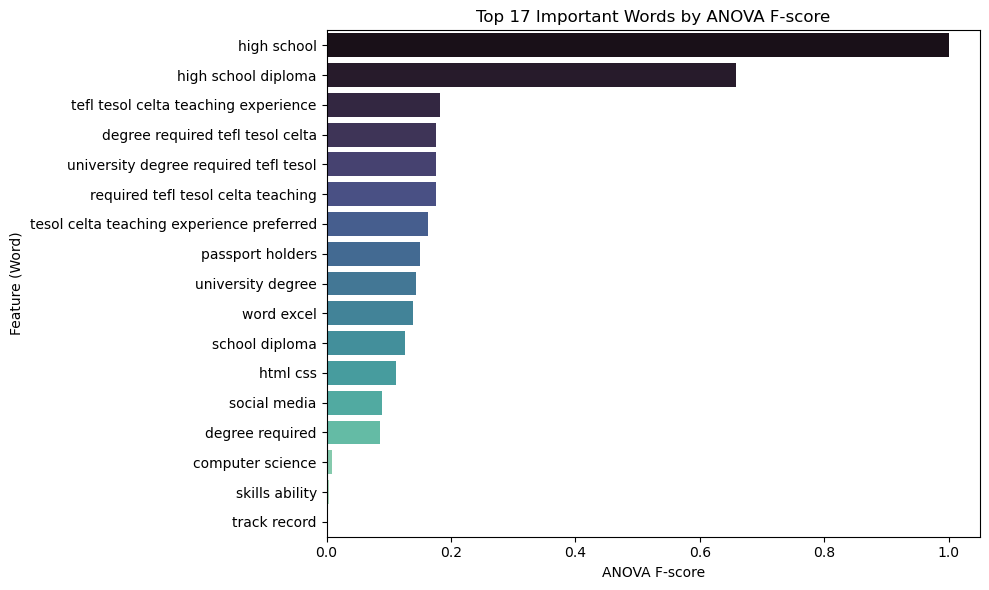

In [219]:
# trimming the feature name for clean visualization
sorted_Scores['shorter_names'] = sorted_Scores['Feature'].str.replace("requirements_includes_", "", regex= False)

sorted_Scores = sorted_Scores.sort_values(by = 'Score', ascending=False)

# normalizing the score 
scaler = MinMaxScaler()
sorted_Scores['Normalized_Scores'] = scaler.fit_transform(sorted_Scores[['Score']])


# barplot of the most important features 
plt.figure(figsize=(10,6))
sns.barplot(x='Normalized_Scores', y='shorter_names', data=sorted_Scores, palette='mako')
plt.title(f'Top {k} Important Words by ANOVA F-score')
plt.xlabel('ANOVA F-score')
plt.ylabel('Feature (Word)')
plt.tight_layout()
plt.show()



In [220]:
X_train_requirements = X_train_k 
print(X_train_requirements.shape)

(14304, 17)


### Benefits - with 62 columns

In [221]:
benefits_df.shape

(17880, 62)

In [222]:
benefits_df['fraudulent'] = new_df['fraudulent']

X = benefits_df.drop(columns="fraudulent")
y = benefits_df["fraudulent"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [223]:
print(y)
print(X)

0        0
1        0
2        0
3        0
4        0
        ..
17875    0
17876    0
17877    0
17878    0
17879    0
Name: fraudulent, Length: 17880, dtype: int64
       benefits_includes_base salary  benefits_includes_benefits include  \
0                                0.0                                 0.0   
1                                0.0                                 0.0   
2                                0.0                                 0.0   
3                                0.0                                 0.0   
4                                0.0                                 0.0   
...                              ...                                 ...   
17875                            0.0                                 0.0   
17876                            0.0                                 0.0   
17877                            0.0                                 0.0   
17878                            0.0                                 0.0 

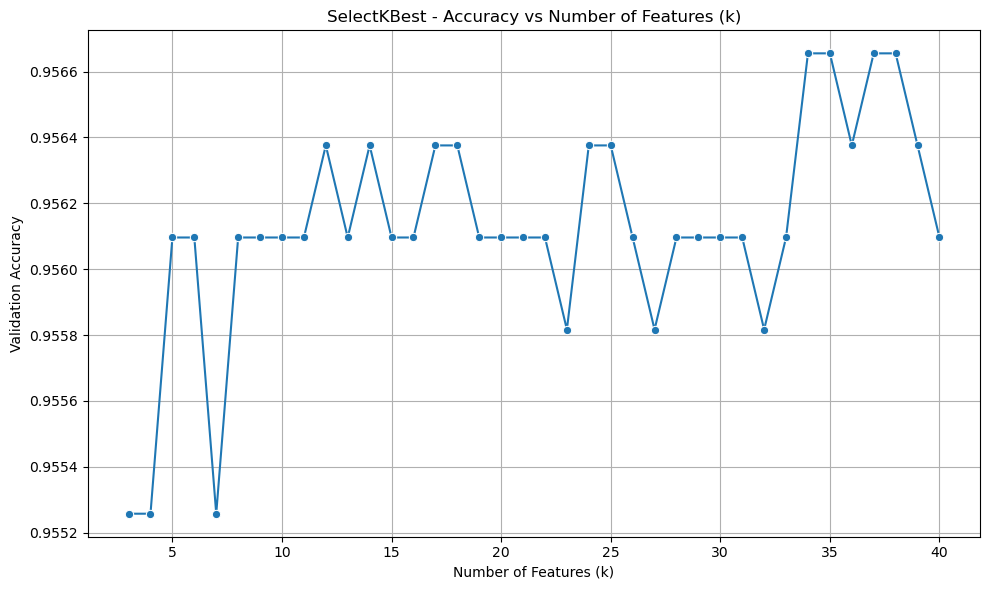

In [224]:
results = []

description_feature_names = X_train.columns

max_k = min(40, len(description_feature_names))

for k in range(3, max_k + 1):
    selector = SelectKBest(f_classif, k=k)
    selector.fit(X_train, y_train)
    selected_cols = description_feature_names[selector.get_support()]

    X_train_desc_k = X_train[selected_cols]
    X_test_desc_k = X_test[selected_cols]

    # fitting random forest model for assessment 

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_desc_k, y_train)

    y_pred = model.predict(X_test_desc_k)
    acc = accuracy_score(y_test, y_pred)
    
    results.append((k, acc))

# Plot accuracy vs. k
results_df = pd.DataFrame(results, columns=["k", "Validation Accuracy"])
plt.figure(figsize=(10,6))
sns.lineplot(x="k", y="Validation Accuracy", data=results_df, marker="o")
plt.title("SelectKBest - Accuracy vs Number of Features (k)")
plt.xlabel("Number of Features (k)")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()

We can discuss the tradesoffs of the amount of features to select - clearly it is very violate based on the k, but also we are only looking at small changes in accuracy AND it is for an unsure model since it is not the entire dataset. 
- do we want more features instead of putting all our eggs into one basket with few features and hoping they apply well to the whole dataset model
- or is it really worth the potential information loss since we want dimensionality reduction/ interpretability 

In [225]:
k = 11
selector = SelectKBest(f_classif, k=k)
selector.fit(X_train, y_train)

selected_mask = selector.get_support()
selected_cols = description_feature_names[selected_mask]

# top features extracted 
X_train_k = X_train[selected_cols]
X_test_k = X_test[selected_cols]

# getting their ranking by scores
all_scores = selector.scores_

selected_scores = all_scores[selected_mask]

# X_train_k.columns

# creating a dataframe with the top selected columns and their scores 

sorted_Scores = pd.DataFrame({
    'Feature': selected_cols,
    'Score': selected_scores
}).sort_values(by = "Score", ascending=False)

benefits_selected_cols = selected_cols

print(sorted_Scores)

                                              Feature       Score
9                         benefits_includes_work life  234.552529
3                       benefits_includes_dental life  101.143937
1              benefits_includes_competitive benefits   83.739226
6                      benefits_includes_life balance   63.721495
10              benefits_includes_working environment   40.563981
8               benefits_includes_see job description   29.424971
2                benefits_includes_competitive salary   18.104295
7                         benefits_includes_paid time   15.927527
4                      benefits_includes_fast growing   15.824443
0   benefits_includes_benefits package full time e...   10.482743
5               benefits_includes_full time employees    9.703304


/var/folders/yz/btvl331d4g54624wdzgx_2hc0000gn/T/ipykernel_69666/3476996707.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Normalized_Scores', y='shorter_names', data=sorted_Scores, palette='mako')


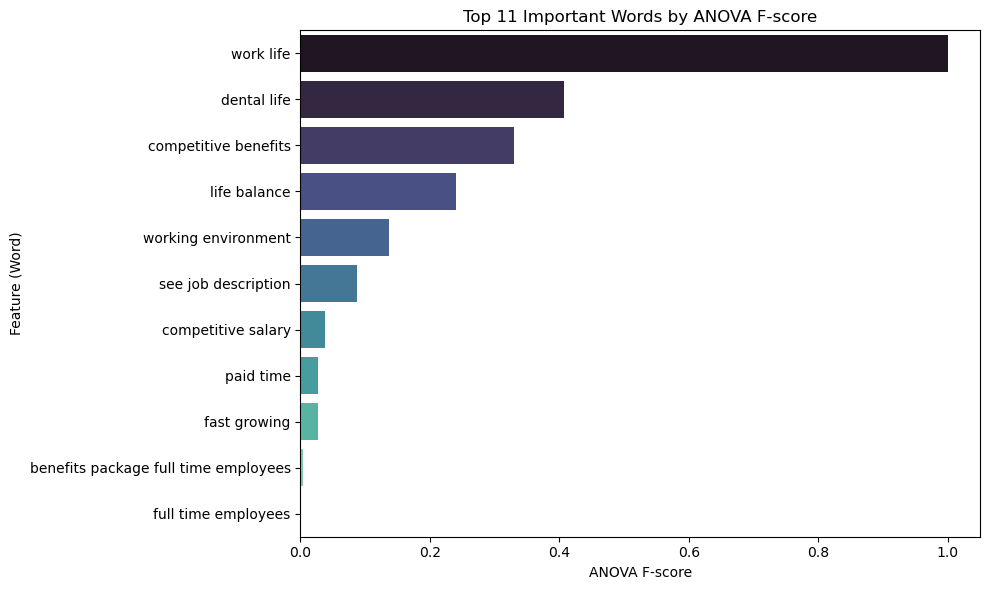

In [226]:
# trimming the feature name for clean visualization
sorted_Scores['shorter_names'] = sorted_Scores['Feature'].str.replace("benefits_includes_", "", regex= False)

sorted_Scores = sorted_Scores.sort_values(by = 'Score', ascending=False)

# normalizing score
scaler = MinMaxScaler()
sorted_Scores['Normalized_Scores'] = scaler.fit_transform(sorted_Scores[['Score']])

# barplot of the most important features 
plt.figure(figsize=(10,6))
sns.barplot(x='Normalized_Scores', y='shorter_names', data=sorted_Scores, palette='mako')
plt.title(f'Top {k} Important Words by ANOVA F-score')
plt.xlabel('ANOVA F-score')
plt.ylabel('Feature (Word)')
plt.tight_layout()
plt.show()

In [227]:
#X_train_benefits = X_train_k 
#print(X_train_benefits.shape)

## Concatenating the K-best columns back into the dataframe

In [228]:
print(new_df.shape)

(17880, 207)


In [229]:
best_categ_df.shape

(17880, 111)

In [230]:
dropped_cols = ['description', 'benefits', 'requirements', 'company_profile']

#for i in dropped_cols:
   # jobs = jobs.drop(i, axis = 1)

print(f'Dims before feature reduction: {new_df.shape}')
'''
jobs_with_top_features = pd.concat([jobs, new_df[description_selected_cols]], axis=1)
jobs_with_top_features = pd.concat([jobs_with_top_features, new_df[req_selected_cols]], axis=1)
jobs_with_top_features = pd.concat([jobs_with_top_features, new_df[benefits_selected_cols]], axis=1)
jobs_with_top_features = pd.concat([jobs_with_top_features, new_df[profile_selected_features]], axis=1)
'''
jobs_with_top_features = pd.concat([
    new_df["fraudulent"],
    new_df[description_selected_cols],
    new_df[req_selected_cols],
    new_df[benefits_selected_cols],
    new_df[profile_selected_features]
], axis=1)
#print(f'Dims after feature reduction: {jobs_with_top_features.shape}')

#jobs_with_top_features["fraudulent"]
#jobs_with_top_features = jobs_with_top_features.drop(columns=dropped_cols)

Dims before feature reduction: (17880, 207)


In [231]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency


# Function to compute Chi-Squared statistic between feature and label
def chi_squared_statistic(feature, label):
    # Create a contingency table
    contingency_table = pd.crosstab(feature, label)
    
    # Compute the Chi-Squared statistic and p-value
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    return chi2

# Calculate Chi-Squared statistics for each feature with respect to the label
chi_squared_values = X.apply(lambda col: chi_squared_statistic(col, y))

# Sort the Chi-Squared values in descending order
chi_squared_values_sorted = chi_squared_values.sort_values(ascending=False)

# Show top N features with highest association to the label
top_n = 10
print("Top 10 features with highest Chi-squared statistic with the label:")
print(chi_squared_values_sorted.head(top_n))


Top 10 features with highest Chi-squared statistic with the label:
benefits_includes_work life                   1247.497498
benefits_includes_benefits package            1073.697884
benefits_includes_life balance                 892.767948
benefits_includes_paid time                    746.417468
benefits_includes_competitive benefits         695.764286
benefits_includes_compensation package         641.929915
benefits_includes_full benefits                622.157450
benefits_includes_competitive compensation     597.421459
benefits_includes_health dental                580.732490
benefits_includes_working environment          558.898938
dtype: float64


### Fitting Random Forest to test effectiveness of dimensionality reduction

In [232]:
X = jobs_with_top_features.drop(columns="fraudulent", axis=1)
y = jobs_with_top_features["fraudulent"].values.ravel()


In [233]:
#X = X.drop(columns=["company_profile", "description", "requirements", "benefits"])
# avoid creating dummy variables for unique columns 

In [234]:
#print(X.dtypes)


In [235]:
X.nunique().sort_values(ascending=False)

requirements_includes_skills ability                                                                 683
requirements_includes_computer science                                                               600
requirements_includes_track record                                                                   437
description_includes_full time                                                                       409
requirements_includes_social media                                                                   360
requirements_includes_html css                                                                       354
requirements_includes_school diploma                                                                 341
description_includes_social media                                                                    335
description_includes_communication skills                                                            308
requirements_includes_word excel                       

In [236]:
X = pd.get_dummies(X, drop_first=True)
# merge in og categorical column best dummies 
X = pd.concat([X, best_categ_df], axis=1)
X = pd.concat([X, sentiment_df], axis = 1)
# fixing non-json column names
X.columns = X.columns.str.replace(r'[\[\]<>]', '_', regex=True)
X.columns = X.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
X = X.loc[:, ~X.columns.duplicated()]

### Do Train/Test/Val Split and Standardize for some models 

* We have enough data to do 15-15-70 split
* Applying SMOTE to validation/testing would no longer be testing/validating on real-world examples 
* Would have overly optimistic performance metrics 
* Scale all data for all models for consistency in ensembles and comparison

In [237]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE


# 1. Train/test/val split (70/15/15)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42)

# 2. Apply SMOTE to the training data only - use for all models 
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 3. Scale data for models that need it
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


In [238]:

# Split the data into training and testing sets
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Logistic Regression (Reduced Model) - scaled and SMOTE

In [239]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train_scaled, y_train_smote)

# Make predictions
y_pred = logreg.predict(X_val_scaled)
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_val, y_pred))

Accuracy: 0.9471
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      2553
           1       0.47      0.79      0.59       130

    accuracy                           0.95      2683
   macro avg       0.73      0.87      0.78      2683
weighted avg       0.96      0.95      0.95      2683



### Random Forest (Scaling although not required)

In [240]:
from sklearn.model_selection import GridSearchCV

# defining parameters for grid search 
grid = {
        'n_estimators': [100, 200, 500],
        'max_depth': [5, 10, 15],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }

# Train a Random Forest model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train_smote)
feature_importances = rf.feature_importances_

# initializing the grid 
grid_search = GridSearchCV(estimator= rf, param_grid = grid, cv=3)

# fitting grid search 
grid_search.fit(X_train, y_train)

# optimal parameters
print("Best parameters:", grid_search.best_params_)
best_rf = grid_search.best_estimator_

accuracy = best_rf.score(X_test, y_test)
print("Test accuracy:", accuracy)

# Make predictions and evaluate the model
y_pred = rf.predict(X_val_scaled)

# Get predicted probabilities for class 1
y_proba = rf.predict_proba(X_val_scaled)[:, 1]

# Apply a lower threshold to increase recall of class 1
threshold = 0.3  # or try 0.25 / 0.2 depending on your tradeoff tolerance
y_pred = (y_proba >= threshold).astype(int)

accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_val, y_pred))

Best parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Test accuracy: 0.9739000745712155
Accuracy: 0.9717
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      2553
           1       0.66      0.88      0.75       130

    accuracy                           0.97      2683
   macro avg       0.82      0.93      0.87      2683
weighted avg       0.98      0.97      0.97      2683



### SVM (Reduced Model)

In [241]:
'''
from sklearn.svm import SVC
svm = SVC(kernel='linear')  # Linear kernel is good choice for text classification
svm.fit(X_train, y_train)

# Make predictions on the test set
y_pred = svm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))
'''


'\nfrom sklearn.svm import SVC\nsvm = SVC(kernel=\'linear\')  # Linear kernel is good choice for text classification\nsvm.fit(X_train, y_train)\n\n# Make predictions on the test set\ny_pred = svm.predict(X_test)\naccuracy = accuracy_score(y_test, y_pred)\nprint(f"Accuracy: {accuracy:.4f}")\nprint(classification_report(y_test, y_pred))\n'

### Bernoulli NB (Because binary dummy variables) - Scaling although not required

In [242]:
from sklearn.naive_bayes import BernoulliNB
nb = BernoulliNB()
nb.fit(X_train_scaled, y_train_smote)
y_pred = nb.predict(X_val_scaled)
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_val, y_pred))

Accuracy: 0.8487
              precision    recall  f1-score   support

           0       0.99      0.85      0.91      2553
           1       0.22      0.85      0.35       130

    accuracy                           0.85      2683
   macro avg       0.61      0.85      0.63      2683
weighted avg       0.95      0.85      0.89      2683



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, classification_report

# Define the model
nb = BernoulliNB()

# Define the parameter grid (usually just alpha for BernoulliNB)
param_grid = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 10.0],  # smoothing parameter
    'fit_prior': [True, False]            # whether to learn class prior probabilities
}

# Set up GridSearchCV
grid_search = GridSearchCV(nb, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit to training data
grid_search.fit(X_train_scaled, y_train_smote)

# Best model
best_nb = grid_search.best_estimator_

# Predict on validation set
y_pred = best_nb.predict(X_val_scaled)

# Evaluate
accuracy = accuracy_score(y_val, y_pred)
print(f"Best Params: {grid_search.best_params_}")
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_val, y_pred))
nb = best_nb


### Light GBM Classifier (Scaling although not required)

In [ ]:
import lightgbm as lgb

best_params = {
    'learning_rate': 0.1,
    'max_depth': 20,
    'n_estimators': 200,
    'num_leaves': 50
}

opt_lgb = lgb.LGBMClassifier(**best_params)
opt_lgb.fit(X_train_scaled, y_train_smote)


# error due to column names

# Predict
y_pred = opt_lgb.predict(X_val_scaled)

# Accuracy
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Classification report
print(classification_report(y_val, y_pred))

# Confusion matrix
#cm = confusion_matrix(y_val, y_pred)
#disp = ConfusionMatrixDisplay(confusion_matrix=cm)
#print(classification_report(y_val, y_pred))
#disp.plot(cmap='Blues')
#plt.title('Confusion Matrix')
#plt.show()

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[LightGBM] [Info] Number of positive: 9527, number of negative: 9527
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026492 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8499
[LightGBM] [Info] Number of data points in the train set: 19054, number of used features: 1013
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/Users/rmclatcher/opt/anaconda3/envs/new_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 9527, number of negative: 9527
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.057627 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8415
[LightGBM] [Info] Number of data points in the train set: 19054, number of used features: 1000
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/Users/rmclatcher/opt/anaconda3/envs/new_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 9527, number of negative: 9527
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026772 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8366
[LightGBM] [Info] Number of data points in the train set: 19054, number of used features: 997
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


...

[LightGBM] [Info] Number of positive: 9528, number of negative: 9527
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023704 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8374
[LightGBM] [Info] Number of data points in the train set: 19055, number of used features: 1012
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500026 -> initscore=0.000105
[LightGBM] [Info] Start training from score 0.000105


/Users/rmclatcher/opt/anaconda3/envs/new_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 9527, number of negative: 9528
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.121114 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8484
[LightGBM] [Info] Number of data points in the train set: 19055, number of used features: 1003
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499974 -> initscore=-0.000105
[LightGBM] [Info] Start training from score -0.000105


/Users/rmclatcher/opt/anaconda3/envs/new_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 11909, number of negative: 11909
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.137364 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9334
[LightGBM] [Info] Number of data points in the train set: 23818, number of used features: 1142
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Accuracy: 0.9758
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2553
           1       0.75      0.75      0.75       130

    accuracy                           0.98      2683
   macro avg       0.87      0.87      0.87      2683
weighted avg       0.98      0.98      0.98      2683



### SGD Classifier (Need scaling)

In [ ]:
from sklearn.linear_model import SGDClassifier
sgd = SGDClassifier(loss='hinge')  # 'hinge' for SVM-like behavior
sgd.fit(X_train_scaled, y_train_smote)
y_pred = sgd.predict(X_val_scaled)


In [ ]:
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_val, y_pred))

Accuracy: 0.9996
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2553
           1       1.00      0.99      1.00       130

    accuracy                           1.00      2683
   macro avg       1.00      1.00      1.00      2683
weighted avg       1.00      1.00      1.00      2683



Way too low of recall for class 1 - we can artificially adjust this using lower threshold (than 0.5) for classification. Use below snippet:

In [ ]:
'''
y_probs = sgd.predict_proba(X_val_scaled)[:, 1]
threshold = 0.3
y_pred_custom = (y_probs > threshold).astype(int)
threshold = 0.3
y_pred_custom = (y_probs > threshold).astype(int)
'''

'\ny_probs = sgd.predict_proba(X_val_scaled)[:, 1]\nthreshold = 0.3\ny_pred_custom = (y_probs > threshold).astype(int)\nthreshold = 0.3\ny_pred_custom = (y_probs > threshold).astype(int)\n'

In [ ]:

# Sort features by importance
sorted_indices = np.argsort(feature_importances)[::-1]  # Indices of features sorted by importance (descending)
sorted_features = [(X.columns[i], feature_importances[i]) for i in sorted_indices]

# Print the top 10 most important features
print("Top 10 Most Important Features:")
for feature, importance in sorted_features[:10]:
    print(f"{feature}: {importance:.4f}")

# feature importances sum up to 1

Top 10 Most Important Features:
fraudulent: 0.3781
has_company_logo: 0.0610
company_profile_word_count: 0.0466
company_profile_subjectivity: 0.0414
company_profile_sentence_count: 0.0411
company_profile_readability: 0.0359
Country_US: 0.0278
company_profile_sentiment: 0.0220
filtered_industry_Oil_Energy: 0.0214
Bachelor_degree: 0.0179


### XGBoost - no scaling needed

In [ ]:
import xgboost as xgb

In [ ]:
X.columns = X.columns.str.replace(r'[\[\]<>]', '_', regex=True)

#### No grid search for XGB - too much time to run

In [ ]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# using split applied above
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
# for imbalanced classes

xgboost = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',  # avoids warning
    random_state=42, 
    scale_pos_weight=scale_pos_weight
)

# Train the model
xgboost.fit(X_train_scaled, y_train_smote)

# Predict
y_pred = xgboost.predict(X_val_scaled)

# Evaluate
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_val, y_pred))

/Users/ellawileman/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [22:48:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.8025
              precision    recall  f1-score   support

           0       1.00      0.80      0.88      2553
           1       0.19      0.95      0.32       130

    accuracy                           0.80      2683
   macro avg       0.59      0.87      0.60      2683
weighted avg       0.96      0.80      0.86      2683



In [ ]:
X.columns

Index(['description_includes_asia_usd_monthly_cost_living',
       'description_includes_cardsgabriel_adkins_url_edcbafbeedcdbdeccddacfdf_url_dbdfcdbecfcabaeaacbfdeb',
       'description_includes_click_apply',
       'description_includes_communication_skills',
       'description_includes_fast_growing', 'description_includes_feel_free',
       'description_includes_full_time', 'description_includes_get_paid',
       'description_includes_integral_part',
       'description_includes_kids_get_paid_love_travel',
       ...
       'Mapped_Title_part_time', 'Mapped_Title_project',
       'Mapped_Title_representative', 'Mapped_Title_sales_manager',
       'Mapped_Title_sales_professional', 'Mapped_Title_sales_representative',
       'Mapped_Title_software_engineer', 'Mapped_Title_technician',
       'Mapped_Title_ux_designer', 'Mapped_Title_web_developer'],
      dtype='object', length=171)

Notes: can also compute length and word counts of unique text fields as an attribute
Can store sentiment of these columns too and see if more useful than the actual tokens.

Otherwise I say we get to comparing models (base learners) and maybe making a meta learner


## Most Important to MAXIMIZE:

Recall for class 1 (detect all fraudulent job postings). Accuracy is not as important when we are considering how imbalanced this dataset is

# Comparing Base Learners

Use feature importance (permutation importance from Sklearn) to see if our models are focusing on the same features! We want them to be really good at learning different features in order to combine in an ensemble that isn’t redundant! How can we measure correlation between models (if they are making same errors?) Prioritize model diversity over accuracy in choosing models for ensemble!
* Compute pearson coefficient (would compare how similar each model’s confidence in their predictions are - not just the label itself for each instance)
predict_proba(X)[:, 1] for each model and get pearson coeff of this
* Compute disagreement rate (between class labels of models -> low disagreement: redundant models)
disagreement = np.mean(preds_model1 != preds_model2) 
* Compute Cohen’s Kappa statistic (minimize for model pairs)
Adjusts for agreement by chance and class imbalance (note we have perfectly balanced classes) 
* Directly compare confusion matrixes
* Q statistic (measures correlation of correct predictions)
* Double fault measure (when are models both wrong?)


In [ ]:
from itertools import combinations
# can avoid comparing sgd because recall of class 1 too low and doesnt have a 
# probabilities function built in
models = [logreg, rf, nb, lgb, xgboost]
model_pairs = list(combinations(models, 2))

In [ ]:
from sklearn.metrics import confusion_matrix, cohen_kappa_score, pairwise_distances
from scipy.stats import pearsonr
import numpy as np

def compare_models(model1, model2, X_test, y_test):
    # Predict the probabilities
    prob_model1 = model1.predict_proba(X_test)[:, 1]
    prob_model2 = model2.predict_proba(X_test)[:, 1]
    preds_model1 = model1.predict(X_test)
    preds_model2 = model2.predict(X_test)

    # Calculate metrics
    pearson_corr, _ = pearsonr(prob_model1, prob_model2)
    disagreement_rate = np.mean(preds_model1 != preds_model2)
    kappa = cohen_kappa_score(preds_model1, preds_model2)
    cm1 = confusion_matrix(y_test, preds_model1)
    cm2 = confusion_matrix(y_test, preds_model2)

    # Calculate Double Fault
    double_fault = np.mean((preds_model1 != y_test) & (preds_model2 != y_test))

    return {
        "pearson_correlation": pearson_corr,
        "disagreement_rate": disagreement_rate,
        "cohen_kappa": kappa,
        "double_fault": double_fault,
        "confusion_matrix_model1": cm1,
        "confusion_matrix_model2": cm2
    }


In [ ]:
comparisons = {}

for model1, model2 in model_pairs:
    comparisons[(model1, model2)] = compare_models(model1, model2, X_test, y_test)

/Users/ellawileman/anaconda3/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/ellawileman/anaconda3/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Users/ellawileman/anaconda3/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/ellawileman/anaconda3/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Users/ellawileman/anaconda3/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/ellawileman/anaconda3/lib/python3.11/site-packages/skle

In [ ]:
comparisons

{(LogisticRegression(),
  RandomForestClassifier(random_state=42)): {'pearson_correlation': 0.17678955221772022, 'disagreement_rate': 0.9821029082774049, 'cohen_kappa': 0.0, 'double_fault': 0.0007457121551081282, 'confusion_matrix_model1': array([[2552,    0],
         [ 130,    0]]), 'confusion_matrix_model2': array([[  46, 2506],
         [   2,  128]])},
 (LogisticRegression(),
  BernoulliNB()): {'pearson_correlation': 0.6960871646398884, 'disagreement_rate': 0.20096942580164057, 'cohen_kappa': 0.0, 'double_fault': 0.00820283370618941, 'confusion_matrix_model1': array([[2552,    0],
         [ 130,    0]]), 'confusion_matrix_model2': array([[2121,  431],
         [  22,  108]])},
 (LogisticRegression(),
  LGBMClassifier()): {'pearson_correlation': 0.2182363561300018, 'disagreement_rate': 0.8012677106636839, 'cohen_kappa': 0.0, 'double_fault': 0.0, 'confusion_matrix_model1': array([[2552,    0],
         [ 130,    0]]), 'confusion_matrix_model2': array([[ 533, 2019],
         [   0, 

# Best Model Pairs for Ensemble Building

## Prioritzing best combinations of these metrics:
Best Candidates for Least Redundancy (High Diversity)

In [ ]:
import itertools
# Generate all combinations of models (pairs)
model_combinations = list(itertools.combinations(models, 2))

# Print the combinations
len(model_combinations)

10

* Bernoulli NB & XGBoost
* Logreg & XGBoost *
* Logreg & Bernoulli NB *
* LR and RF
* LGBMClassifier(), XGBClassifier()
* BernoulliNB(), LGBMClassifier()

## Ensembles of Best Pairs using Soft Voting

Using soft voting because all models calculate class probabilities and we will take those into consideration rather than each model outputing a class label

In [ ]:
from sklearn.ensemble import VotingClassifier

nb_xgb = VotingClassifier(
    estimators=[
        ('nb', nb),
        ('xgb', xgboost)
    ],
    voting='soft'
)

# use scaled version for consistency
nb_xgb.fit(X_train_scaled, y_train_smote)
y_pred = nb_xgb.predict(X_val_scaled)

# Evaluate
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Cohen Kappa:", cohen_kappa_score(y_val, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))


/Users/ellawileman/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [22:48:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.8177413343272456
Cohen Kappa: 0.2808654037471011
Confusion Matrix:
 [[2069  484]
 [   5  125]]


Adjusting classification threshold

In [ ]:
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score

# Function to calculate metrics for different thresholds
def evaluate_threshold(y_true, y_prob, thresholds):
    results = []
    for threshold in thresholds:
        # Make predictions based on the threshold
        y_pred = (y_prob[:, 1] >= threshold).astype(int)
        
        # Calculate the precision, recall, and f1-score
        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        
        results.append({
            'Threshold': threshold,
            'Precision': precision,
            'Recall': recall,
            'F1-score': f1
        })
    return results

# Get predicted probabilities from the ensemble model
y_prob = nb_xgb.predict_proba(X_val)  # X_test is your test set

# Define different threshold values to test
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

# Evaluate for each threshold
metrics_results = evaluate_threshold(y_val, y_prob, thresholds)

# Print out the results
for result in metrics_results:
    print(f"Threshold: {result['Threshold']} -> Precision: {result['Precision']:.3f}, Recall: {result['Recall']:.3f}, F1-score: {result['F1-score']:.3f}")


Threshold: 0.3 -> Precision: 0.049, Recall: 1.000, F1-score: 0.093
Threshold: 0.4 -> Precision: 0.062, Recall: 1.000, F1-score: 0.117
Threshold: 0.5 -> Precision: 0.128, Recall: 1.000, F1-score: 0.227
Threshold: 0.6 -> Precision: 0.173, Recall: 0.992, F1-score: 0.295
Threshold: 0.7 -> Precision: 0.199, Recall: 0.954, F1-score: 0.329


/Users/ellawileman/anaconda3/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but BernoulliNB was fitted without feature names
  warnings.warn(


We are ok prioritizing recall over precision - but still too much trade off

### Try optimal classification threshold

In [ ]:
# Trying to adjust the threshold for classification
from sklearn.metrics import classification_report

# Get predicted probabilities from your model
y_pred_proba = nb_xgb.predict_proba(X_val)[:, 1]  # Probabilities for class 1 (fraudulent)

# Choose a new threshold (e.g., 0.3 for more recall, 0.7 for more precision)
threshold = 0.7
y_pred_new = (y_pred_proba >= threshold).astype(int)

# Evaluate with the new threshold
print(classification_report(y_val, y_pred_new))

              precision    recall  f1-score   support

           0       1.00      0.80      0.89      2553
           1       0.20      0.95      0.33       130

    accuracy                           0.81      2683
   macro avg       0.60      0.88      0.61      2683
weighted avg       0.96      0.81      0.86      2683



/Users/ellawileman/anaconda3/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but BernoulliNB was fitted without feature names
  warnings.warn(


Still, half of predicted fraudulent class is not fraudulent. 

### Ensemble 2: ADD LGBM
* LGBM is best overall
* NB has really good recall for class 1
* Logreg has most balanced precision/recall tradeoff

In [ ]:
withLGBM = VotingClassifier(
    estimators=[('lr', logreg), ('nb', nb), ('lgbm', lgb)],
    voting='soft',
    weights=[1, 1, 2]
    # weighting LGBM more because it is best overall model
)

In [ ]:
# use scaled version for consistency
withLGBM.fit(X_train_scaled, y_train_smote)
y_pred = withLGBM.predict(X_val_scaled)

# Evaluate
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Cohen Kappa:", cohen_kappa_score(y_val, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))

[LightGBM] [Info] Number of positive: 11909, number of negative: 11909
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.046039 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6422
[LightGBM] [Info] Number of data points in the train set: 23818, number of used features: 171
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Accuracy: 0.9366380916884085
Cohen Kappa: 0.5452542372881355
Confusion Matrix:
 [[2398  155]
 [  15  115]]


Major reduction in number of misclassifications!

### Looking for best model weights (these 3 models)

In [ ]:
# Commented out because took ~4-5 mins to run
'''
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, cohen_kappa_score

# Define the weight combinations you want to try
weight_combos = [
    (1, 1, 1),  # Equal weights for all models
    (0, 1, 2),  # Higher weight on LGBM
    (1, 0, 2),  # Higher weight on LGBM
    (1, 1, 2),  # Higher weight on LGBM
    (0, 0, 1),  # Very light weight on LGBM
    (2, 1, 3),  # Heavier weight on LGBM and logreg
    (1, 2, 2),  # Moderate weight on Logreg, and LGBM
    (1, 1, 3),  # Slightly higher weight on LGBM
]

# Function to train and evaluate VotingClassifier with different weights
def test_combo(weights):
    model = VotingClassifier(
        estimators=[('lr', logreg), ('nb', nb), ('lgbm', lgb)],
        voting='soft',
        weights=weights
    )
    
    # Fit the model
    model.fit(X_train_scaled, y_train_smote)
    
    # Predict and evaluate
    y_pred = model.predict(X_val_scaled)
    accuracy = accuracy_score(y_val, y_pred)
    cohen_kappa = cohen_kappa_score(y_val, y_pred)
    
    # Return the results
    return weights, accuracy, cohen_kappa

# Perform the search
results = []
for weights in weight_combos:
    weights, accuracy, cohen_kappa = test_combo(weights)
    results.append((weights, accuracy, cohen_kappa))

# Output results
for weights, accuracy, cohen_kappa in results:
    print(f"Weights: {weights} | Accuracy: {accuracy:.4f} | Cohen Kappa: {cohen_kappa:.4f}")
'''

'\nfrom sklearn.ensemble import VotingClassifier\nfrom sklearn.metrics import accuracy_score, cohen_kappa_score\n\n# Define the weight combinations you want to try\nweight_combos = [\n    (1, 1, 1),  # Equal weights for all models\n    (0, 1, 2),  # Higher weight on LGBM\n    (1, 0, 2),  # Higher weight on LGBM\n    (1, 1, 2),  # Higher weight on LGBM\n    (0, 0, 1),  # Very light weight on LGBM\n    (2, 1, 3),  # Heavier weight on LGBM and logreg\n    (1, 2, 2),  # Moderate weight on Logreg, and LGBM\n    (1, 1, 3),  # Slightly higher weight on LGBM\n]\n\n# Function to train and evaluate VotingClassifier with different weights\ndef test_combo(weights):\n    model = VotingClassifier(\n        estimators=[(\'lr\', logreg), (\'nb\', nb), (\'lgbm\', lgb)],\n        voting=\'soft\',\n        weights=weights\n    )\n    \n    # Fit the model\n    model.fit(X_train_scaled, y_train_smote)\n    \n    # Predict and evaluate\n    y_pred = model.predict(X_val_scaled)\n    accuracy = accuracy_scor

In [ ]:
# Best weights are [1,0,2] - logistic regression and lgbm 
# makes sense with our model comparison results quantifying model redundancy

In [ ]:
lr_lgbm = VotingClassifier(
    estimators=[('lr', logreg), ('lgbm', lgb)],
    voting='soft',
    weights=[1, 2]
    # weighting LGBM more because it is best overall model
)

# use scaled version for consistency
lr_lgbm.fit(X_train_scaled, y_train_smote)
y_pred = lr_lgbm.predict(X_val_scaled)

# Evaluate
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Cohen Kappa:", cohen_kappa_score(y_val, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))

[LightGBM] [Info] Number of positive: 11909, number of negative: 11909
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.080251 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6422
[LightGBM] [Info] Number of data points in the train set: 23818, number of used features: 171
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Accuracy: 0.9511740588893031
Cohen Kappa: 0.6003386295849457
Confusion Matrix:
 [[2443  110]
 [  21  109]]
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      2553
           1       0.50      0.84      0.62       130

    accuracy                           0.95      2683
   macro avg       0.74      0.90      0.80      2683
weighted avg       0.97      0.95      0.96      2683



Decreased misclassification again! Now we can adjust the classification threshold for our use case - prioritize recall

### Threshold Tuning for class 1 Recall

/Users/ellawileman/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


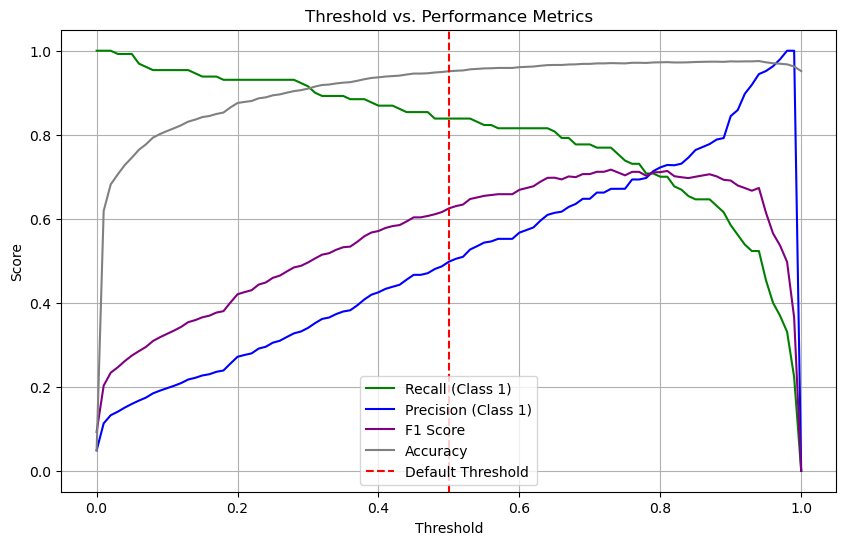

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
)

# Get class 1 probabilities from VotingClassifier
probs = lr_lgbm.predict_proba(X_val_scaled)[:, 1]

# Threshold sweep
thresholds = np.linspace(0.0, 1.0, 101)
recalls = []
precisions = []
f1s = []
accuracies = []

for threshold in thresholds:
    y_pred_thresh = (probs >= threshold).astype(int)
    
    recalls.append(recall_score(y_val, y_pred_thresh))
    precisions.append(precision_score(y_val, y_pred_thresh))
    f1s.append(f1_score(y_val, y_pred_thresh))
    accuracies.append(accuracy_score(y_val, y_pred_thresh))

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(thresholds, recalls, label='Recall (Class 1)', color='green')
plt.plot(thresholds, precisions, label='Precision (Class 1)', color='blue')
plt.plot(thresholds, f1s, label='F1 Score', color='purple')
plt.plot(thresholds, accuracies, label='Accuracy', color='gray')
plt.axvline(0.5, color='red', linestyle='--', label='Default Threshold')
plt.title('Threshold vs. Performance Metrics')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()


Try decreasing threshold to increase recall of class 1

In [ ]:
'''
y_proba = lr_lgbm.predict_proba(X_val_scaled)[:, 1]

# Apply custom threshold (e.g., 0.3)
threshold = 0.3
y_pred = (y_proba >= threshold).astype(int)

# Evaluate
print("Threshold:", threshold)
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Cohen Kappa:", cohen_kappa_score(y_val, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))
'''

'\ny_proba = lr_lgbm.predict_proba(X_val_scaled)[:, 1]\n\n# Apply custom threshold (e.g., 0.3)\nthreshold = 0.3\ny_pred = (y_proba >= threshold).astype(int)\n\n# Evaluate\nprint("Threshold:", threshold)\nprint("Accuracy:", accuracy_score(y_val, y_pred))\nprint("Cohen Kappa:", cohen_kappa_score(y_val, y_pred))\nprint("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))\nprint(classification_report(y_val, y_pred))\n'

Not worth it -- keep version above that doesn't adjust threshold

### RF and LGBM 

In [ ]:
lgbm_rf = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('lgb', lgb)
    ],
    voting='soft'
)

# use scaled version for consistency
lgbm_rf.fit(X_train_scaled, y_train_smote)
y_pred = lgbm_rf.predict(X_val_scaled)

# Evaluate
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Cohen Kappa:", cohen_kappa_score(y_val, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))

[LightGBM] [Info] Number of positive: 11909, number of negative: 11909
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.038532 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6422
[LightGBM] [Info] Number of data points in the train set: 23818, number of used features: 171
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Accuracy: 0.9645918747670518
Cohen Kappa: 0.6659974866436997
Confusion Matrix:
 [[2485   68]
 [  27  103]]
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2553
           1       0.60      0.79      0.68       130

    accuracy                           0.96      2683
   macro avg       0.80      0.88      0.83      2683
weighted avg       0.97      0.96      0.97      2683



### RF and XGB 

In [ ]:
xgb_rf = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgboost)
    ],
    voting='soft'
)

# use scaled version for consistency
xgb_rf.fit(X_train_scaled, y_train_smote)
y_pred = xgb_rf.predict(X_val_scaled)

# Evaluate
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Cohen Kappa:", cohen_kappa_score(y_val, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))

/Users/ellawileman/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [22:48:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.9273201639955274
Cohen Kappa: 0.5147215551616574
Confusion Matrix:
 [[2370  183]
 [  12  118]]
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      2553
           1       0.39      0.91      0.55       130

    accuracy                           0.93      2683
   macro avg       0.69      0.92      0.75      2683
weighted avg       0.97      0.93      0.94      2683



### XGB and LR

In [ ]:
xgb_lr = VotingClassifier(
    estimators=[
        ('lr', logreg),
        ('xgb', xgboost)
    ],
    voting='soft'
)

# use scaled version for consistency
xgb_lr.fit(X_train_scaled, y_train_smote)
y_pred = xgb_lr.predict(X_val_scaled)

# Evaluate
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Cohen Kappa:", cohen_kappa_score(y_val, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))

/Users/ellawileman/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [22:48:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.868803578084234
Cohen Kappa: 0.3609778145865643
Confusion Matrix:
 [[2209  344]
 [   8  122]]
              precision    recall  f1-score   support

           0       1.00      0.87      0.93      2553
           1       0.26      0.94      0.41       130

    accuracy                           0.87      2683
   macro avg       0.63      0.90      0.67      2683
weighted avg       0.96      0.87      0.90      2683



### RF and NB

In [ ]:
nb_rf = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('nb', nb)
    ],
    voting='soft'
)

# use scaled version for consistency
nb_rf.fit(X_train_scaled, y_train_smote)
y_pred = nb_rf.predict(X_val_scaled)

# Evaluate
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Cohen Kappa:", cohen_kappa_score(y_val, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))

Accuracy: 0.9347745061498323
Cohen Kappa: 0.5418405611983524
Confusion Matrix:
 [[2391  162]
 [  13  117]]
              precision    recall  f1-score   support

           0       0.99      0.94      0.96      2553
           1       0.42      0.90      0.57       130

    accuracy                           0.93      2683
   macro avg       0.71      0.92      0.77      2683
weighted avg       0.97      0.93      0.95      2683



# 

### Try RF and LR

In [ ]:
lr_rf = VotingClassifier(
    estimators=[
        ('lr', logreg),
        ('rf', rf)
    ],
    voting='soft'
)

# use scaled version for consistency
lr_rf.fit(X_train_scaled, y_train_smote)
y_pred = lr_rf.predict(X_val_scaled)

# Evaluate
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Cohen Kappa:", cohen_kappa_score(y_val, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))


Accuracy: 0.9597465523667537
Cohen Kappa: 0.6461338556906498
Confusion Matrix:
 [[2467   86]
 [  22  108]]


Finding Optimal Weights for this Ensemble 

In [ ]:
# took 15 minutes to run 
'''
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import cohen_kappa_score, accuracy_score, confusion_matrix
import numpy as np

best_score = -1
best_weights = None

# Try weights for lr from 1 to 5, and rf from 1 to 5
for w1 in range(1, 6):
    for w2 in range(1, 6):
        clf = VotingClassifier(
            estimators=[('lr', logreg), ('rf', rf)],
            voting='soft',
            weights=[w1, w2]
        )
        clf.fit(X_train_scaled, y_train_smote)
        y_pred = clf.predict(X_val_scaled)

        kappa = cohen_kappa_score(y_val, y_pred)
        if kappa > best_score:
            best_score = kappa
            best_weights = (w1, w2)
            print(f"New best: Weights={best_weights}, Kappa={best_score:.4f}")

print(f"\nBest weights: {best_weights}, Best Cohen Kappa: {best_score:.4f}")
'''


'\nfrom sklearn.ensemble import VotingClassifier\nfrom sklearn.metrics import cohen_kappa_score, accuracy_score, confusion_matrix\nimport numpy as np\n\nbest_score = -1\nbest_weights = None\n\n# Try weights for lr from 1 to 5, and rf from 1 to 5\nfor w1 in range(1, 6):\n    for w2 in range(1, 6):\n        clf = VotingClassifier(\n            estimators=[(\'lr\', logreg), (\'rf\', rf)],\n            voting=\'soft\',\n            weights=[w1, w2]\n        )\n        clf.fit(X_train_scaled, y_train_smote)\n        y_pred = clf.predict(X_val_scaled)\n\n        kappa = cohen_kappa_score(y_val, y_pred)\n        if kappa > best_score:\n            best_score = kappa\n            best_weights = (w1, w2)\n            print(f"New best: Weights={best_weights}, Kappa={best_score:.4f}")\n\nprint(f"\nBest weights: {best_weights}, Best Cohen Kappa: {best_score:.4f}")\n'

Incorporate Optimal Weights (LR = 1, RF = 2)

In [ ]:
lr_rf_wts = VotingClassifier(
    estimators=[('lr', logreg), ('rf', rf)],
    voting='soft',
    weights=[1, 2]
)

In [ ]:
# use scaled version for consistency
lr_rf_wts.fit(X_train_scaled, y_train_smote)
y_pred = lr_rf_wts.predict(X_val_scaled)


# Evaluate
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Cohen Kappa:", cohen_kappa_score(y_val, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))

Accuracy: 0.9701826313827805
Cohen Kappa: 0.7104608560991534
Confusion Matrix:
 [[2497   56]
 [  24  106]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      2553
           1       0.65      0.82      0.73       130

    accuracy                           0.97      2683
   macro avg       0.82      0.90      0.86      2683
weighted avg       0.97      0.97      0.97      2683



Can we prioritize the recall of class 1 over the precision? Tried changing the threshold and got more misclassifications so not worth adjusting tradeoff. Let's incorporate NB because it has high precision and low recall for class 1 (complementary strengths)

Created more misclassifications when adding LGBM. Use RF & LogReg alone

Could also try stacking instead of voting?